In [1]:
from pathlib import Path
import urllib.request
import tarfile


BASE_DIR = Path("protein_dimensionality_experiments")
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)


DATASETS = {
    "remote_homology": {
        "url": "http://s3.amazonaws.com/songlabdata/proteindata/data_raw_pytorch/remote_homology.tar.gz",
    },
    "secondary_structure": {
        "url": "http://s3.amazonaws.com/songlabdata/proteindata/data_raw_pytorch/secondary_structure.tar.gz",
    },
    "fluorescence": {
        "url": "http://s3.amazonaws.com/songlabdata/proteindata/data_raw_pytorch/fluorescence.tar.gz",
    },
    "stability": {
        "url": "http://s3.amazonaws.com/songlabdata/proteindata/data_raw_pytorch/stability.tar.gz",
    },
}


def download_file(url, output_path):
    if output_path.exists():
        print(f"Already exists: {output_path}")
        return

    print(f"Downloading: {url}")
    urllib.request.urlretrieve(url, output_path)
    print(f"Saved: {output_path}")


def extract_tarball(tar_path, output_dir):
    marker = output_dir / ".extracted"

    if marker.exists():
        print(f"Already extracted: {output_dir}")
        return

    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting: {tar_path}")

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(output_dir)

    marker.touch()
    print(f"Extracted to: {output_dir}")


for name, config in DATASETS.items():

    dataset_dir = DATA_DIR / name
    archive_path = DATA_DIR / f"{name}.tar.gz"

    dataset_dir.mkdir(parents=True, exist_ok=True)

    download_file(
        config["url"],
        archive_path,
    )

    extract_tarball(
        archive_path,
        dataset_dir,
    )


print("\nDataset download complete.")
print(f"Location: {DATA_DIR.resolve()}")

Already exists: protein_dimensionality_experiments/data/remote_homology.tar.gz
Already extracted: protein_dimensionality_experiments/data/remote_homology
Already exists: protein_dimensionality_experiments/data/secondary_structure.tar.gz
Already extracted: protein_dimensionality_experiments/data/secondary_structure
Already exists: protein_dimensionality_experiments/data/fluorescence.tar.gz
Already extracted: protein_dimensionality_experiments/data/fluorescence
Already exists: protein_dimensionality_experiments/data/stability.tar.gz
Already extracted: protein_dimensionality_experiments/data/stability

Dataset download complete.
Location: /Users/jamesjr/Documents/ml_hands_on_challenge/ml_biosciences_submission/protein_dimensionality_experiments/data


In [2]:
for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path)


for dataset_dir in sorted(DATA_DIR.iterdir()):
    if dataset_dir.is_dir():
        print(f"\n{'=' * 60}")
        print(dataset_dir.name)
        print("=" * 60)

        for path in sorted(dataset_dir.rglob("*")):
            if path.is_file():
                print(path.relative_to(dataset_dir))

protein_dimensionality_experiments/data/secondary_structure.tar.gz
protein_dimensionality_experiments/data/remote_homology.tar.gz
protein_dimensionality_experiments/data/fluorescence.tar.gz
protein_dimensionality_experiments/data/stability.tar.gz
protein_dimensionality_experiments/data/secondary_structure/.extracted
protein_dimensionality_experiments/data/secondary_structure/secondary_structure/secondary_structure_valid.json
protein_dimensionality_experiments/data/secondary_structure/secondary_structure/secondary_structure_train.json
protein_dimensionality_experiments/data/secondary_structure/secondary_structure/secondary_structure_cb513.json
protein_dimensionality_experiments/data/secondary_structure/secondary_structure/secondary_structure_casp12.json
protein_dimensionality_experiments/data/secondary_structure/secondary_structure/secondary_structure_ts115.json
protein_dimensionality_experiments/data/remote_homology/.extracted
protein_dimensionality_experiments/data/remote_homology/rem

ESM-2 DIMENSIONALITY EXPERIMENT
Dataset: remote_homology
Target: class_label
Model: facebook/esm2_t33_650M_UR50D
Device: mps
Dimensions: [32, 64, 128, 256, 512, 768, 1024, 1280]

Dataset files:
Train: protein_dimensionality_experiments/data/remote_homology/remote_homology/remote_homology_train.json
Valid: protein_dimensionality_experiments/data/remote_homology/remote_homology/remote_homology_valid.json
Test : protein_dimensionality_experiments/data/remote_homology/remote_homology/remote_homology_test_family_holdout.json

Dataset sizes:
Train: 12312
Valid: 736
Test : 1272

Example record:
{'id': 'd1v4wb_', 'primary': 'VEWTQQERSIIAGIFANLNYEDIGPKALARCLIVYPWTQRYFGAYGDLSTPDAIKGNAKIAAHGVKVLHGLDRAVKNMDNINEAYSELSVLHSDKLHVDPDNFRILGDCLTVVIAANLGDAFTVETQCAFQKFLAVVVFALGRKYH', 'protein_length': 146, 'class_label': 0, 'fold_label': 0, 'superfamily_label': 0, 'family_label': 0, 'secondary_structure': [[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0],

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Hidden size: 1280
Parameters: 652353941

Generating ESM-2 embeddings...
  Embedded 16 / 12,312
  Embedded 2,000 / 12,312
  Embedded 4,000 / 12,312
  Embedded 6,000 / 12,312
  Embedded 8,000 / 12,312
  Embedded 10,000 / 12,312
  Embedded 12,000 / 12,312
  Embedded 12,312 / 12,312
  Embedded 16 / 736
  Embedded 736 / 736
  Embedded 16 / 1,272
  Embedded 1,272 / 1,272

Embeddings saved:
protein_dimensionality_experiments/embeddings/remote_homology_class_label_esm2_1280d.npz

Embedding shapes:
Train: (12312, 1280)
Valid: (736, 1280)
Test : (1272, 1280)

Fitting PCA on training embeddings...


RUNNING DIMENSIONALITY EXPERIMENT

D = 32


python(5238) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5239) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5240) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5241) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5242) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5243) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5244) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5245) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5246) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5247) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5248) MallocStackLoggin

Train accuracy : 0.8002
Valid accuracy : 0.7391
Test accuracy  : 0.8373
Test Macro-F1  : 0.6241
Explained var. : 0.7676

D = 64
Train accuracy : 0.8574
Valid accuracy : 0.7880
Test accuracy  : 0.9009
Test Macro-F1  : 0.8220
Explained var. : 0.8326

D = 128
Train accuracy : 0.9207
Valid accuracy : 0.8451
Test accuracy  : 0.9607
Test Macro-F1  : 0.9147
Explained var. : 0.8906

D = 256
Train accuracy : 0.9497
Valid accuracy : 0.8899
Test accuracy  : 0.9764
Test Macro-F1  : 0.9709
Explained var. : 0.9399

D = 512
Train accuracy : 0.9638
Valid accuracy : 0.9049
Test accuracy  : 0.9811
Test Macro-F1  : 0.9789
Explained var. : 0.9770

D = 768
Train accuracy : 0.9677
Valid accuracy : 0.9076
Test accuracy  : 0.9827
Test Macro-F1  : 0.9798
Explained var. : 0.9910

D = 1024
Train accuracy : 0.9704
Valid accuracy : 0.9076
Test accuracy  : 0.9827
Test Macro-F1  : 0.9799
Explained var. : 0.9973

D = 1280
Train accuracy : 0.9709
Valid accuracy : 0.9090
Test accuracy  : 0.9827
Test Macro-F1  : 0.9799


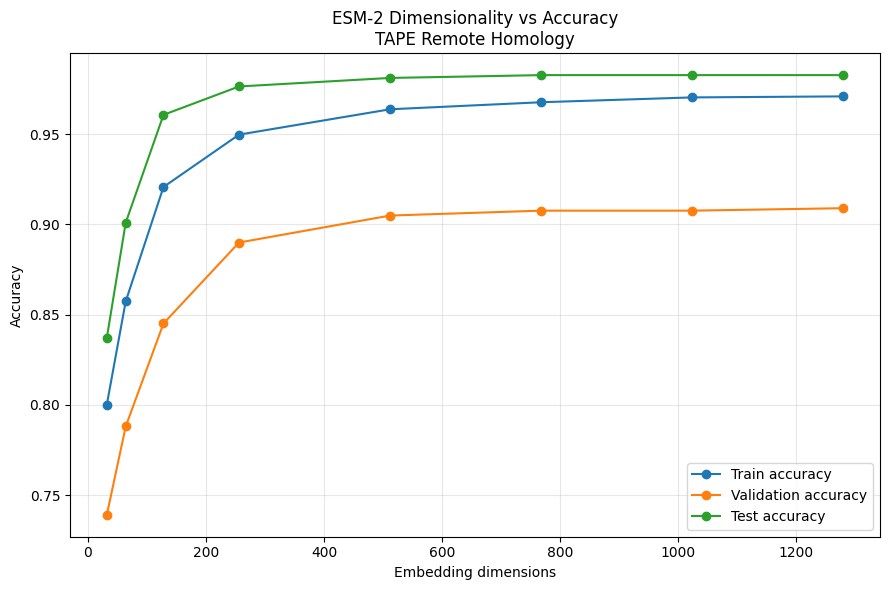

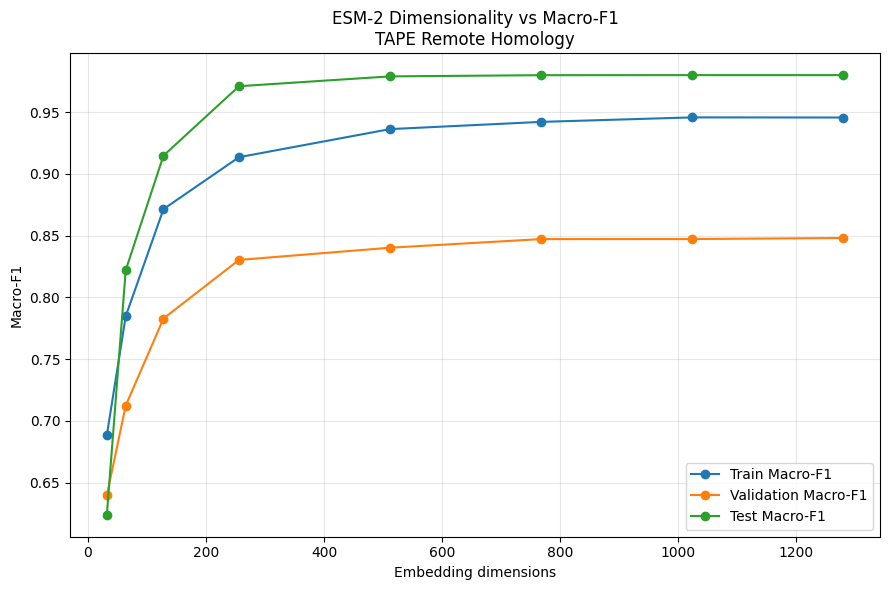

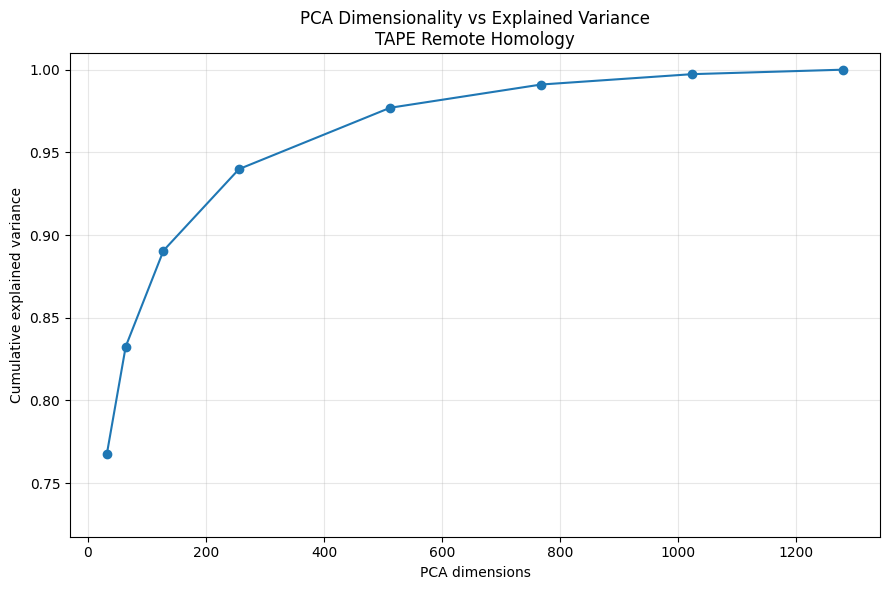



EXPERIMENT SUMMARY
Best D by test accuracy: 768
Test accuracy: 0.9827
Test Macro-F1: 0.9798
Explained variance: 0.9910

Output directory:
/Users/jamesjr/Documents/ml_hands_on_challenge/ml_biosciences_submission/protein_dimensionality_experiments/results

Experiment complete.


In [3]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel


# ============================================================
# CONFIGURATION
# ============================================================

SEED = 42

MODEL_NAME = "facebook/esm2_t33_650M_UR50D"

BASE_DIR = Path("protein_dimensionality_experiments")
DATA_DIR = BASE_DIR / "data"
EMBEDDING_DIR = BASE_DIR / "embeddings"
RESULTS_DIR = BASE_DIR / "results"

EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "remote_homology"

# Remote homology target.
# Options:
#   class_label
#   fold_label
#   superfamily_label
#   family_label
TARGET_COLUMN = "class_label"

DIMS = [
    32,
    64,
    128,
    256,
    512,
    768,
    1024,
    1280,
]

BATCH_SIZE = 16
MAX_LENGTH = 512
CLASSIFIER_MAX_ITER = 1000


# ============================================================
# REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# DEVICE
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


print("=" * 70)
print("ESM-2 DIMENSIONALITY EXPERIMENT")
print("=" * 70)

print("Dataset:", DATASET_NAME)
print("Target:", TARGET_COLUMN)
print("Model:", MODEL_NAME)
print("Device:", device)
print("Dimensions:", DIMS)


# ============================================================
# DATASET PATHS
# ============================================================

DATASET_DIR = (
    DATA_DIR
    / DATASET_NAME
    / DATASET_NAME
)

TRAIN_FILE = (
    DATASET_DIR
    / "remote_homology_train.json"
)

VALID_FILE = (
    DATASET_DIR
    / "remote_homology_valid.json"
)

# Primary test set for this experiment.
TEST_FILE = (
    DATASET_DIR
    / "remote_homology_test_family_holdout.json"
)


for path in [
    TRAIN_FILE,
    VALID_FILE,
    TEST_FILE,
]:

    if not path.exists():
        raise FileNotFoundError(
            f"Required dataset file not found:\n{path}"
        )


print("\nDataset files:")
print("Train:", TRAIN_FILE)
print("Valid:", VALID_FILE)
print("Test :", TEST_FILE)


# ============================================================
# LOAD JSON
# ============================================================

def load_json(path):

    with open(path, "r") as f:
        return json.load(f)


train_data = load_json(TRAIN_FILE)
valid_data = load_json(VALID_FILE)
test_data = load_json(TEST_FILE)


print("\nDataset sizes:")
print("Train:", len(train_data))
print("Valid:", len(valid_data))
print("Test :", len(test_data))


# ============================================================
# INSPECT DATA
# ============================================================

print("\nExample record:")
print(train_data[0])


# ============================================================
# EXTRACT SEQUENCES AND LABELS
# ============================================================

def convert_dataset(
    dataset,
    target_column,
):

    sequences = []
    labels = []

    for record in dataset:

        if "primary" not in record:
            raise ValueError(
                "Missing 'primary' sequence field."
            )

        if target_column not in record:
            raise ValueError(
                f"Missing target column "
                f"'{target_column}'."
            )

        sequences.append(
            str(record["primary"])
        )

        labels.append(
            int(record[target_column])
        )

    return (
        sequences,
        np.asarray(
            labels,
            dtype=np.int64,
        ),
    )


train_sequences, y_train = convert_dataset(
    train_data,
    TARGET_COLUMN,
)

valid_sequences, y_valid = convert_dataset(
    valid_data,
    TARGET_COLUMN,
)

test_sequences, y_test = convert_dataset(
    test_data,
    TARGET_COLUMN,
)


# ============================================================
# DATASET SUMMARY
# ============================================================

print("\nDataset summary")

print(
    "Train sequences:",
    len(train_sequences)
)

print(
    "Valid sequences:",
    len(valid_sequences)
)

print(
    "Test sequences :",
    len(test_sequences)
)

print(
    "\nNumber of training classes:",
    len(np.unique(y_train))
)

print("\nTraining class distribution:")

print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nValidation class distribution:")

print(
    pd.Series(y_valid)
    .value_counts()
    .sort_index()
)

print("\nTest class distribution:")

print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)


# ============================================================
# SEQUENCE LENGTH ANALYSIS
# ============================================================

train_lengths = np.array(
    [len(seq) for seq in train_sequences]
)

valid_lengths = np.array(
    [len(seq) for seq in valid_sequences]
)

test_lengths = np.array(
    [len(seq) for seq in test_sequences]
)


print("\nSequence length statistics:")

print(
    pd.Series(train_lengths).describe()
)

print(
    "\nTrain > 512:",
    np.sum(train_lengths > MAX_LENGTH),
    f"({np.mean(train_lengths > MAX_LENGTH) * 100:.2f}%)"
)

print(
    "Valid > 512:",
    np.sum(valid_lengths > MAX_LENGTH),
    f"({np.mean(valid_lengths > MAX_LENGTH) * 100:.2f}%)"
)

print(
    "Test > 512:",
    np.sum(test_lengths > MAX_LENGTH),
    f"({np.mean(test_lengths > MAX_LENGTH) * 100:.2f}%)"
)


# ============================================================
# LOAD ESM-2
# ============================================================

print("\nLoading ESM-2...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
)

model = model.to(device)
model.eval()

print(
    "Hidden size:",
    model.config.hidden_size
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)


# ============================================================
# ESM-2 EMBEDDING FUNCTION
# ============================================================

@torch.inference_mode()
def embed_sequences(
    sequences,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
):

    embeddings = []

    for start in range(
        0,
        len(sequences),
        batch_size,
    ):

        batch = [
            str(seq).strip().upper()
            for seq in sequences[
                start:start + batch_size
            ]
        ]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        outputs = model(**inputs)

        hidden = outputs.last_hidden_state

        attention_mask = inputs[
            "attention_mask"
        ]

        # Remove BOS/EOS.
        hidden = hidden[:, 1:-1, :]
        attention_mask = attention_mask[:, 1:-1]

        mask = attention_mask.unsqueeze(-1)

        hidden = hidden * mask

        pooled = (
            hidden.sum(dim=1)
            /
            mask.sum(dim=1).clamp(min=1)
        )

        embeddings.append(
            pooled
            .float()
            .cpu()
            .numpy()
        )

        processed = min(
            start + batch_size,
            len(sequences),
        )

        if (
            start == 0
            or processed % 1000 == 0
            or processed == len(sequences)
        ):

            print(
                f"  Embedded "
                f"{processed:,} / "
                f"{len(sequences):,}"
            )

    return np.concatenate(
        embeddings,
        axis=0,
    )


# ============================================================
# EMBEDDING CACHE
# ============================================================

embedding_file = (
    EMBEDDING_DIR
    /
    f"{DATASET_NAME}_"
    f"{TARGET_COLUMN}_"
    f"esm2_1280d.npz"
)


if embedding_file.exists():

    print(
        "\nLoading cached embeddings:"
    )

    print(embedding_file)

    cached = np.load(
        embedding_file
    )

    X_train = cached["X_train"]
    X_valid = cached["X_valid"]
    X_test = cached["X_test"]

else:

    print(
        "\nGenerating ESM-2 embeddings..."
    )

    X_train = embed_sequences(
        train_sequences
    )

    X_valid = embed_sequences(
        valid_sequences
    )

    X_test = embed_sequences(
        test_sequences
    )

    np.savez_compressed(
        embedding_file,
        X_train=X_train,
        X_valid=X_valid,
        X_test=X_test,
    )

    print(
        "\nEmbeddings saved:"
    )

    print(embedding_file)


# ============================================================
# EMBEDDING VALIDATION
# ============================================================

print("\nEmbedding shapes:")

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

assert X_train.shape[1] == 1280
assert X_valid.shape[1] == 1280
assert X_test.shape[1] == 1280


# ============================================================
# PCA
# ============================================================

print(
    "\nFitting PCA on training embeddings..."
)

pca = PCA(
    n_components=1280,
    random_state=SEED,
)

X_train_pca = pca.fit_transform(
    X_train
)

X_valid_pca = pca.transform(
    X_valid
)

X_test_pca = pca.transform(
    X_test
)


# ============================================================
# EXPLAINED VARIANCE
# ============================================================

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)


# ============================================================
# DIMENSIONALITY EXPERIMENT
# ============================================================

results = []

print("\n")
print("=" * 70)
print("RUNNING DIMENSIONALITY EXPERIMENT")
print("=" * 70)


for d in DIMS:

    print(f"\nD = {d}")

    Xtr = X_train_pca[:, :d]
    Xva = X_valid_pca[:, :d]
    Xte = X_test_pca[:, :d]

    classifier = LogisticRegression(
        max_iter=CLASSIFIER_MAX_ITER,
        random_state=SEED,
        n_jobs=-1,
    )

    classifier.fit(
        Xtr,
        y_train,
    )

    train_pred = classifier.predict(Xtr)
    valid_pred = classifier.predict(Xva)
    test_pred = classifier.predict(Xte)

    train_accuracy = accuracy_score(
        y_train,
        train_pred,
    )

    valid_accuracy = accuracy_score(
        y_valid,
        valid_pred,
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred,
    )

    train_f1 = f1_score(
        y_train,
        train_pred,
        average="macro",
    )

    valid_f1 = f1_score(
        y_valid,
        valid_pred,
        average="macro",
    )

    test_f1 = f1_score(
        y_test,
        test_pred,
        average="macro",
    )

    variance = cumulative_variance[d - 1]

    results.append({

        "D": d,

        "train_accuracy":
            train_accuracy,

        "valid_accuracy":
            valid_accuracy,

        "test_accuracy":
            test_accuracy,

        "train_macro_f1":
            train_f1,

        "valid_macro_f1":
            valid_f1,

        "test_macro_f1":
            test_f1,

        "explained_variance":
            variance,
    })

    print(
        f"Train accuracy : "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Valid accuracy : "
        f"{valid_accuracy:.4f}"
    )

    print(
        f"Test accuracy  : "
        f"{test_accuracy:.4f}"
    )

    print(
        f"Test Macro-F1  : "
        f"{test_f1:.4f}"
    )

    print(
        f"Explained var. : "
        f"{variance:.4f}"
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


# ============================================================
# SAVE RESULTS
# ============================================================

results_file = (
    RESULTS_DIR
    /
    f"{DATASET_NAME}_"
    f"{TARGET_COLUMN}_"
    f"dimensionality_results.csv"
)

results_df.to_csv(
    results_file,
    index=False,
)

print(
    "\nResults saved:"
)

print(results_file)


# ============================================================
# SAVE PCA INFORMATION
# ============================================================

pca_file = (
    RESULTS_DIR
    /
    f"{DATASET_NAME}_"
    f"{TARGET_COLUMN}_pca.npz"
)

np.savez_compressed(
    pca_file,
    explained_variance_ratio=(
        pca.explained_variance_ratio_
    ),
    cumulative_variance=(
        cumulative_variance
    ),
)

print(
    "PCA information saved:"
)

print(pca_file)


# ============================================================
# PLOT 1 — ACCURACY
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["D"],
    results_df["train_accuracy"],
    marker="o",
    label="Train accuracy",
)

plt.plot(
    results_df["D"],
    results_df["valid_accuracy"],
    marker="o",
    label="Validation accuracy",
)

plt.plot(
    results_df["D"],
    results_df["test_accuracy"],
    marker="o",
    label="Test accuracy",
)

plt.xlabel(
    "Embedding dimensions"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ESM-2 Dimensionality vs Accuracy\n"
    "TAPE Remote Homology"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

accuracy_plot = (
    RESULTS_DIR
    /
    f"{DATASET_NAME}_"
    f"{TARGET_COLUMN}_"
    f"accuracy_vs_dimension.png"
)

plt.savefig(
    accuracy_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 2 — MACRO-F1
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["D"],
    results_df["train_macro_f1"],
    marker="o",
    label="Train Macro-F1",
)

plt.plot(
    results_df["D"],
    results_df["valid_macro_f1"],
    marker="o",
    label="Validation Macro-F1",
)

plt.plot(
    results_df["D"],
    results_df["test_macro_f1"],
    marker="o",
    label="Test Macro-F1",
)

plt.xlabel(
    "Embedding dimensions"
)

plt.ylabel(
    "Macro-F1"
)

plt.title(
    "ESM-2 Dimensionality vs Macro-F1\n"
    "TAPE Remote Homology"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

f1_plot = (
    RESULTS_DIR
    /
    f"{DATASET_NAME}_"
    f"{TARGET_COLUMN}_"
    f"macro_f1_vs_dimension.png"
)

plt.savefig(
    f1_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 3 — EXPLAINED VARIANCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["D"],
    results_df["explained_variance"],
    marker="o",
)

plt.xlabel(
    "PCA dimensions"
)

plt.ylabel(
    "Cumulative explained variance"
)

plt.title(
    "PCA Dimensionality vs Explained Variance\n"
    "TAPE Remote Homology"
)

plt.ylim(
    max(
        0,
        results_df[
            "explained_variance"
        ].min() - 0.05,
    ),
    1.01,
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

variance_plot = (
    RESULTS_DIR
    /
    f"{DATASET_NAME}_"
    f"{TARGET_COLUMN}_"
    f"explained_variance.png"
)

plt.savefig(
    variance_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# BEST RESULT
# ============================================================

best_idx = results_df[
    "test_accuracy"
].idxmax()

best = results_df.loc[
    best_idx
]


print("\n")
print("=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)

print(
    f"Best D by test accuracy: "
    f"{int(best['D'])}"
)

print(
    f"Test accuracy: "
    f"{best['test_accuracy']:.4f}"
)

print(
    f"Test Macro-F1: "
    f"{best['test_macro_f1']:.4f}"
)

print(
    f"Explained variance: "
    f"{best['explained_variance']:.4f}"
)

print(
    "\nOutput directory:"
)

print(
    RESULTS_DIR.resolve()
)

print(
    "\nExperiment complete."
)

# Analysis and Findings

## 1. Objective

The objective of this experiment was to investigate how the dimensionality of protein representations derived from **ESM-2** affects downstream protein classification performance.

The initial experiments on a five-class protein dataset produced classification performance close to the theoretical chance level of approximately 20%. This raised an important question: whether the observed performance was caused by the dimensionality of the protein representation, the dimensionality-reduction method, the downstream classifier, the dataset itself, or the biological difficulty of the task.

To investigate this systematically, the **TAPE Remote Homology** dataset was used as a more biologically structured classification benchmark.

ESM-2 was used to generate fixed 1280-dimensional protein representations. PCA was then used to construct representations with dimensionalities:

> **32, 64, 128, 256, 512, 768, 1024, and 1280**

A logistic-regression classifier was trained independently at each dimensionality.

The experiment therefore asks:

> **How much of the information contained in the original ESM-2 representation is required to achieve strong downstream protein classification performance?**

---

## 2. Dataset Characteristics

The Remote Homology dataset used in this experiment contained:

| Split      | Number of sequences |
| ---------- | ------------------: |
| Training   |              12,312 |
| Validation |                 736 |
| Test       |               1,272 |

Seven classes were represented in the training set.

The training distribution was:

| Class | Training sequences |
| ----: | -----------------: |
|     0 |              2,201 |
|     1 |              3,009 |
|     2 |              2,845 |
|     3 |              2,939 |
|     4 |                214 |
|     5 |                205 |
|     6 |                899 |

The dataset is therefore not perfectly class-balanced. This is important when interpreting classification accuracy because accuracy can be dominated by the larger classes.

For this reason, **Macro-F1** was also reported. Macro-F1 gives equal importance to each class and provides a more informative measure of performance when class frequencies differ substantially.

---

## 3. Sequence Length Analysis

The training sequences had the following length distribution:

| Statistic          |         Length |
| ------------------ | -------------: |
| Mean               | 167.2 residues |
| Standard deviation | 108.8 residues |
| Minimum            |    17 residues |
| Median             |   134 residues |
| 75th percentile    |   217 residues |
| Maximum            | 1,419 residues |

ESM-2 embedding extraction used a maximum sequence length of 512 residues.

Only a small fraction of sequences exceeded this limit:

| Split      | Sequences >512 residues |
| ---------- | ----------------------: |
| Training   |                   1.22% |
| Validation |                   1.49% |
| Test       |                   0.79% |

Therefore, sequence truncation affects only a small proportion of the dataset and is unlikely to be the primary explanation for the dimensionality-dependent performance observed in this experiment.

Nevertheless, long-sequence handling should be investigated in future experiments because truncation could remove biologically relevant regions from individual proteins.

---

# 4. ESM-2 Representation

The experiment used:

```text
facebook/esm2_t33_650M_UR50D
```

The model contains approximately 652 million parameters and produces a **1280-dimensional residue representation**.

Protein-level representations were generated using masked mean pooling over residue tokens.

The resulting embedding matrices were:

```text
Train: (12312, 1280)
Valid: (736, 1280)
Test : (1272, 1280)
```

The original 1280-dimensional representation was subsequently reduced using PCA.

Importantly, PCA was fitted **only on the training embeddings** and then applied to the validation and test embeddings. This prevents information from the validation or test sets from influencing the learned PCA transformation.

---

# 5. Dimensionality Experiment

The dimensionality experiment produced the following results:

| Dimensions | Explained Variance | Train Accuracy | Validation Accuracy | Test Accuracy | Test Macro-F1 |
| ---------: | -----------------: | -------------: | ------------------: | ------------: | ------------: |
|         32 |             76.76% |         80.02% |              73.91% |        83.73% |        0.6241 |
|         64 |             83.26% |         85.74% |              78.80% |        90.09% |        0.8220 |
|        128 |             89.06% |         92.07% |              84.51% |        96.07% |        0.9147 |
|        256 |             93.99% |         94.97% |              88.99% |        97.64% |        0.9709 |
|        512 |             97.70% |         96.38% |              90.49% |        98.11% |        0.9789 |
|        768 |             99.10% |         96.77% |              90.76% |    **98.27%** |    **0.9798** |
|       1024 |             99.73% |         97.04% |              90.76% |    **98.27%** |    **0.9799** |
|       1280 |            100.00% |         97.09% |              90.90% |    **98.27%** |    **0.9799** |

---

# 6. Finding 1 — Dimensionality Has a Strong Effect on Classification Performance

The results demonstrate a clear relationship between representation dimensionality and downstream classification performance.

Test accuracy increased substantially as dimensionality increased:

```text
32D   → 83.73%
64D   → 90.09%
128D  → 96.07%
256D  → 97.64%
512D  → 98.11%
768D  → 98.27%
```

The largest gains occurred at low dimensionalities.

In particular:

```text
32D → 128D
83.73% → 96.07%
```

represents a gain of **12.34 percentage points**.

Similarly:

```text
32D → 256D
83.73% → 97.64%
```

represents a gain of **13.91 percentage points**.

This provides strong evidence that aggressive dimensionality reduction can remove information that is useful for protein classification.

Therefore, dimensionality is not merely a computational consideration. It can directly affect the biological information available to the downstream classifier.

---

# 7. Finding 2 — Classification Performance Saturates

Although increasing dimensionality improves performance initially, the improvement eventually saturates.

The transition from 256D to 768D produces only a relatively small additional gain:

```text
256D → 768D

Test accuracy:
97.64% → 98.27%

Macro-F1:
0.9709 → 0.9798
```

The subsequent increase from 768D to the complete 1280-dimensional representation produces essentially no improvement:

```text
768D:
98.27% accuracy
0.9798 Macro-F1

1280D:
98.27% accuracy
0.9799 Macro-F1
```

This indicates that, for this particular classification task and classifier, most of the useful discriminative information is already accessible by approximately 768 dimensions.

Additional dimensions increase the retained variance but do not produce a measurable improvement in classification accuracy.

---

# 8. Finding 3 — Variance Preservation and Classification Performance Are Related but Not Identical

PCA explained variance increased monotonically with dimensionality:

```text
32D   → 76.76%
64D   → 83.26%
128D  → 89.06%
256D  → 93.99%
512D  → 97.70%
768D  → 99.10%
1024D → 99.73%
1280D → 100.00%
```

However, classification performance does not increase at exactly the same rate.

For example, increasing dimensionality from 768D to 1280D increases explained variance from:

```text
99.10% → 100.00%
```

but test accuracy remains unchanged at:

```text
98.27%
```

This demonstrates an important distinction:

> **Variance retained by PCA is not equivalent to task-relevant information retained by PCA.**

Some dimensions may explain relatively little total variance while still containing information that is useful for a particular biological prediction task.

Conversely, dimensions that account for additional variance do not necessarily improve classification.

This is an important consideration when selecting the dimensionality of learned biological representations.

---

# 9. Finding 4 — 256D Provides Strong Compression with Limited Performance Loss

The 256-dimensional representation is particularly interesting.

Compared with the original ESM-2 representation:

```text
1280D → 256D
```

represents an **80% reduction in dimensionality**.

Despite this reduction, the classifier achieved:

```text
Test accuracy: 97.64%
Test Macro-F1: 0.9709
Explained variance: 93.99%
```

The difference between 256D and the best observed test accuracy is only:

```text
98.27% - 97.64% = 0.63 percentage points
```

Therefore, 256D represents a potentially useful compression point where most of the predictive performance is retained while substantially reducing representation size.

However, this should not yet be interpreted as a universally optimal dimensionality. The appropriate dimensionality is expected to depend on the downstream biological task.

---

# 10. Finding 5 — The Result Contrasts Strongly with the Initial Five-Class Experiment

The initial five-class experiment produced approximately chance-level performance across dimensionalities.

In contrast, the Remote Homology experiment produced:

```text
32D   → 83.73%
64D   → 90.09%
128D  → 96.07%
256D  → 97.64%
512D  → 98.11%
768D  → 98.27%
1280D → 98.27%
```

This is an important finding.

It indicates that the approximately 20% performance observed in the initial experiment cannot simply be interpreted as evidence that ESM-2 representations are unsuitable for protein classification.

Instead, the results suggest that **dataset structure, label definition, biological task difficulty, and representation dimensionality all need to be considered together**.

The Remote Homology experiment demonstrates that ESM-2 representations can support highly accurate classification when the downstream task contains sufficiently strong biological structure.

---

# 11. Finding 6 — Accuracy Alone Is Not Sufficient

The dataset contains substantial class imbalance.

This is reflected in the difference between accuracy and Macro-F1, particularly at low dimensionalities.

At 32 dimensions:

```text
Test accuracy = 83.73%
Test Macro-F1 = 0.6241
```

The large difference indicates that high overall accuracy does not necessarily imply uniformly strong performance across classes.

At 256 dimensions:

```text
Test accuracy = 97.64%
Test Macro-F1 = 0.9709
```

the two metrics become much more closely aligned.

This suggests that increasing representation dimensionality does not merely improve aggregate classification performance; it also substantially improves performance across the class distribution.

Future experiments should therefore continue to report:

* Accuracy
* Macro-F1
* Per-class precision
* Per-class recall
* Confusion matrices
* Balanced accuracy

---

# 12. Methodological Considerations

The current results are strong, but several methodological questions remain before drawing broader conclusions.

### 12.1 Target-label definition

The Remote Homology records contain multiple hierarchical labels:

```text
class_label
fold_label
superfamily_label
family_label
```

The current experiment uses:

```text
class_label
```

while the selected test set is:

```text
remote_homology_test_family_holdout.json
```

Therefore, the current experiment should be described as **classification using the `class_label` target under the family-holdout split**, rather than automatically referring to it as family-level remote-homology classification.

The next experiment should explicitly investigate the hierarchical labels and determine whether `family_label`, `superfamily_label`, or `fold_label` better represents the intended remote-homology benchmark.

---

### 12.2 Test-set structure

The dataset provides multiple holdout configurations:

```text
test_family_holdout
test_superfamily_holdout
test_fold_holdout
```

These splits represent different levels of biological separation between training and testing data.

Evaluating all three will allow us to determine whether dimensionality affects:

* interpolation among related proteins,
* generalisation across families,
* generalisation across superfamilies, and
* more distant structural relationships.

This is likely to produce a much more informative scientific result than evaluating a single split.

---

### 12.3 Pooling strategy

The current experiment uses mean pooling of residue representations.

However, protein-level information may not be optimally represented by simple mean pooling.

Future experiments should compare:

```text
Mean pooling
Max pooling
Mean + Max pooling
BOS representation
Attention-weighted pooling
```

This would help determine whether the observed dimensionality relationship is robust to the method used to convert residue-level representations into protein-level representations.

---

### 12.4 Classifier dependence

The current experiment uses logistic regression.

This provides a useful and relatively simple baseline because the ESM-2 representations remain fixed and the classifier is lightweight.

However, the dimensionality curve may depend on classifier capacity.

The next stage should therefore compare:

```text
Logistic Regression
Linear SVM
k-NN
MLP
```

A particularly important control is a **direct linear classifier on the original 1280-dimensional ESM-2 embeddings without PCA**.

This would provide a clean baseline against which every PCA representation can be compared.

---

# 13. Improvements Moving Forward

The next stage should focus on establishing whether the observed dimensionality effect is robust and biologically meaningful.

## Priority 1 — Validate the Remote Homology hierarchy

Before expanding the experiment, inspect:

```text
class_label
fold_label
superfamily_label
family_label
```

and quantify:

* number of unique labels,
* class distributions,
* train/test label overlap,
* family overlap,
* superfamily overlap,
* fold overlap.

This establishes exactly what biological generalisation the current result represents.

---

## Priority 2 — Evaluate all Remote Homology holdout levels

Run the same dimensionality sweep on:

```text
test_family_holdout.json
test_superfamily_holdout.json
test_fold_holdout.json
```

This would allow us to construct a much stronger analysis of:

> **Representation dimensionality versus biological distance between training and test proteins.**

A potentially valuable result would be determining whether more difficult biological generalisation requires higher-dimensional representations.

---

## Priority 3 — Add the raw 1280D baseline

The current PCA experiment includes 1280D, which provides a useful full-dimensional PCA control.

However, we should additionally train directly on the original ESM-2 embeddings:

```text
ESM-2 1280D
       ↓
Linear classifier
       ↓
5/7/etc. classes
```

This verifies that the PCA transformation itself does not introduce an unexpected effect.

---

## Priority 4 — Repeat experiments across random seeds

The current experiment uses a single seed.

The most important dimensionality points should be repeated across multiple seeds:

```text
42
123
456
789
2026
```

Results should then be reported as:

```text
mean ± standard deviation
```

rather than a single measurement.

This is particularly important when comparing small performance differences such as:

```text
97.64% vs 98.11%
```

because the difference may be smaller than experimental variability.

---

## Priority 5 — Evaluate minority-class performance

Because classes 4 and 5 contain very few examples, we should generate:

* confusion matrices,
* per-class F1,
* per-class recall,
* balanced accuracy.

This will determine whether the excellent overall performance is consistent across all biological categories.

---

## Priority 6 — Investigate sequence length

Although only approximately 1% of sequences exceed 512 residues, we should explicitly test:

```text
sequence length < 128
128–256
256–512
>512
```

and determine whether classification performance changes with sequence length.

For the >512 group, we could compare:

```text
512-residue truncation
vs.
full-sequence/chunked pooling
```

to determine whether truncation affects individual predictions.

---

## Priority 7 — Compare pooling strategies

The dimensionality experiment should eventually become a two-dimensional experimental design:

```text
                 Representation dimensionality
              32  64  128  256  512  768  1024  1280
              │   │    │    │    │    │     │     │
Mean          ───────────────────────────────────────
Max           ───────────────────────────────────────
Mean + Max    ───────────────────────────────────────
BOS           ───────────────────────────────────────
```

This would determine whether the dimensionality effect is intrinsic to the ESM-2 representation or partly caused by the pooling method.

---

# 14. Broader Scientific Interpretation

The current results support a more nuanced interpretation of protein representation dimensionality.

The experiment does **not** show that higher dimensionality is always better.

Instead, the results indicate three distinct regimes:

### Low-dimensional regime

```text
32–128D
```

Aggressive compression causes substantial performance degradation.

Important discriminative information has been discarded.

### Intermediate regime

```text
256–512D
```

Most of the task-relevant information has been retained.

Performance becomes very high while the representation is substantially smaller than the original 1280-dimensional representation.

### Saturation regime

```text
768–1280D
```

Additional dimensions preserve more total variance but provide almost no additional downstream classification performance.

This suggests that the relationship between dimensionality and biological prediction is better characterized as a **saturation curve** rather than a simple assumption that more dimensions always produce better predictions.

---

# 15. Current Conclusion

The Remote Homology experiment provides strong evidence that **ESM-2 representation dimensionality can have a substantial effect on downstream protein classification performance**.

Classification performance increased rapidly as dimensionality increased from 32 to 256 dimensions, with test accuracy improving from **83.73% to 97.64%** and Macro-F1 increasing from **0.6241 to 0.9709**.

Performance subsequently approached a plateau, reaching **98.27% test accuracy at 768 dimensions**, with no additional accuracy improvement when increasing dimensionality to 1024 or 1280 dimensions.

The results therefore suggest that a substantial portion of the discriminative information contained in the 1280-dimensional ESM-2 representation can be retained in a lower-dimensional representation. In particular, **256 dimensions provides an 80% reduction in representation dimensionality while retaining 97.64% test accuracy**, although 768 dimensions produced the highest observed accuracy.

The experiment also demonstrates that **PCA explained variance should not be treated as a direct proxy for task-relevant biological information**. Although explained variance increases continuously with dimensionality, classification performance saturates well before the complete variance of the original representation is retained.

The results further indicate that the approximately 20% performance observed in the initial five-class experiment should not be attributed to ESM-2 dimensionality alone. The strong performance obtained on Remote Homology demonstrates that the interaction between representation dimensionality, biological task structure, label definition, dataset composition, and downstream classifier is critical.

The next phase should therefore move beyond a single dimensionality sweep and investigate **hierarchical remote-homology targets, multiple biological holdout levels, classifier dependence, pooling strategies, sequence-length effects, minority-class performance, and statistical reproducibility across random seeds**.

Ultimately, the goal is to determine whether there exists a general relationship between **ESM-2 representation dimensionality, biological task complexity, and generalisation distance**. Establishing such a relationship would provide a stronger scientific basis for selecting compact protein representations rather than choosing dimensionality solely on computational convenience or explained variance.


REMOTE HOMOLOGY HIERARCHICAL DIMENSIONALITY EXPERIMENT
Device: mps
Model : facebook/esm2_t33_650M_UR50D
Seed  : 42

DATASET SUMMARY
Train sequences: 12312
Valid sequences: 736
Family Holdout sequences: 1272
Superfamily Holdout sequences: 1254
Fold Holdout sequences: 718

LABEL CARDINALITY
              split            target  n_sequences  n_unique_labels  min_label  max_label
              train       class_label        12312                7          0          6
              train        fold_label        12312             1195          0       1194
              train superfamily_label        12312             1462          0       1822
              train      family_label        12312             2251          0       3439
              valid       class_label          736                7          0          6
              valid        fold_label          736              319          0        456
              valid superfamily_label          736              511          0  

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Hidden size: 1280
Parameters: 652353941

Generating ESM-2 embeddings...
  Embedded 2,000 / 16,292
  Embedded 4,000 / 16,292
  Embedded 6,000 / 16,292
  Embedded 8,000 / 16,292
  Embedded 10,000 / 16,292
  Embedded 12,000 / 16,292
  Embedded 14,000 / 16,292
  Embedded 16,000 / 16,292
  Embedded 16,292 / 16,292

Embeddings saved:
protein_dimensionality_experiments/embeddings/remote_homology_all_esm2_1280d_51a7b3b26f3e.npz
Embedding dimension: 1280


TARGET: class_label
Training classes: 7
Validation classes: 7

Fitting PCA on training embeddings...

--------------------------------------------------------------------------------
HOLDOUT: family_holdout
--------------------------------------------------------------------------------
Train classes: 7
Test classes : 7
Unseen test classes: 0

Target=class_label | Holdout=family_holdout | D=32


python(6779) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6780) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6781) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6782) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6783) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6784) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6785) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6786) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6787) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6788) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Train accuracy : 0.8004
Valid accuracy : 0.7391
Test accuracy  : 0.8388
Test Macro-F1  : 0.6256
Balanced Acc.  : 0.6228
Explained var. : 0.7671

Target=class_label | Holdout=family_holdout | D=64
Train accuracy : 0.8571
Valid accuracy : 0.7867
Test accuracy  : 0.9009
Test Macro-F1  : 0.8220
Balanced Acc.  : 0.7908
Explained var. : 0.8321

Target=class_label | Holdout=family_holdout | D=128
Train accuracy : 0.9207
Valid accuracy : 0.8465
Test accuracy  : 0.9599
Test Macro-F1  : 0.9142
Balanced Acc.  : 0.8862
Explained var. : 0.8902

Target=class_label | Holdout=family_holdout | D=256
Train accuracy : 0.9499
Valid accuracy : 0.8899
Test accuracy  : 0.9764
Test Macro-F1  : 0.9709
Balanced Acc.  : 0.9597
Explained var. : 0.9396

Target=class_label | Holdout=family_holdout | D=512
Train accuracy : 0.9637
Valid accuracy : 0.9035
Test accuracy  : 0.9811
Test Macro-F1  : 0.9789
Balanced Acc.  : 0.9712
Explained var. : 0.9768

Target=class_label | Holdout=family_holdout | D=768
Train accuracy :

...

Train accuracy : 0.9143
Valid accuracy : 0.0761
Test accuracy  : 0.9607
Test Macro-F1  : 0.9095
Balanced Acc.  : 0.9350
Explained var. : 0.9909

Target=family_label | Holdout=family_holdout | D=1024


python(8491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8492) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8493) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8494) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8495) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8496) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8497) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8498) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8499) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Train accuracy : 0.9190
Valid accuracy : 0.0774
Test accuracy  : 0.9623
Test Macro-F1  : 0.9146
Balanced Acc.  : 0.9374
Explained var. : 0.9973

Target=family_label | Holdout=family_holdout | D=1280


python(8528) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8529) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8530) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8531) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8532) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8533) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8534) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8535) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8536) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Train accuracy : 0.9213
Valid accuracy : 0.0774
Test accuracy  : 0.9623
Test Macro-F1  : 0.9118
Balanced Acc.  : 0.9374
Explained var. : 1.0000

--------------------------------------------------------------------------------
HOLDOUT: superfamily_holdout
--------------------------------------------------------------------------------
Train classes: 2251
Test classes : 791
Unseen test classes: 791

Classification SKIPPED for this target/holdout combination.
Reason: test contains labels that do not occur in training.

--------------------------------------------------------------------------------
HOLDOUT: fold_holdout
--------------------------------------------------------------------------------
Train classes: 2251
Test classes : 398
Unseen test classes: 398

Classification SKIPPED for this target/holdout combination.
Reason: test contains labels that do not occur in training.


FINAL RESULTS
           target             holdout    D  train_accuracy  valid_accuracy  test_accuracy  tr

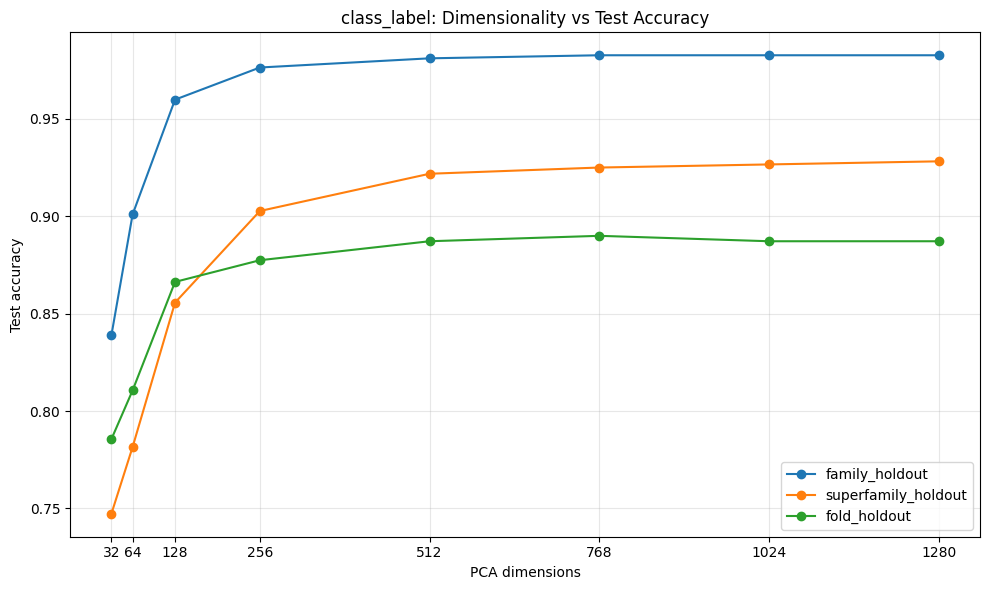

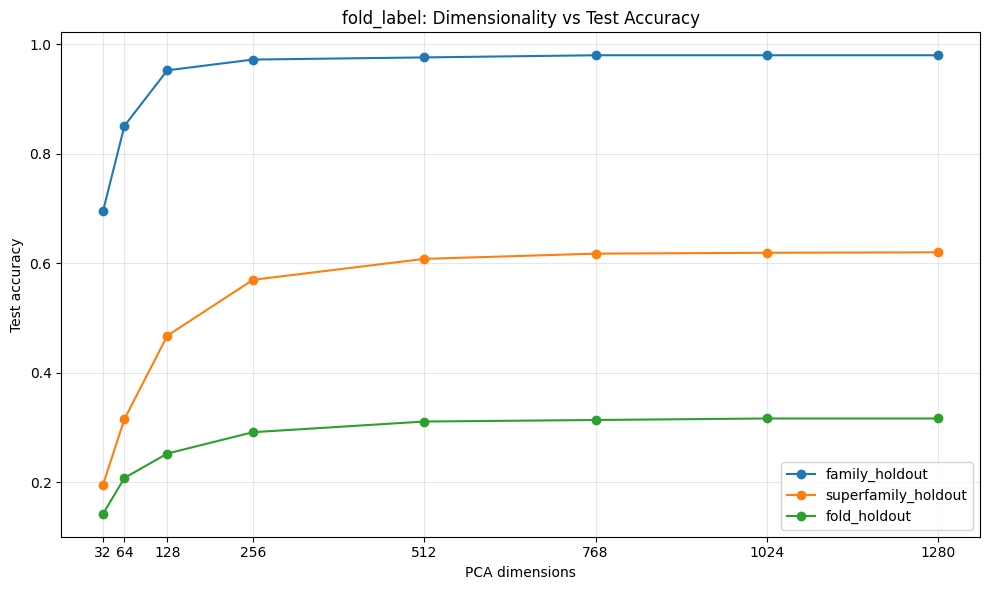

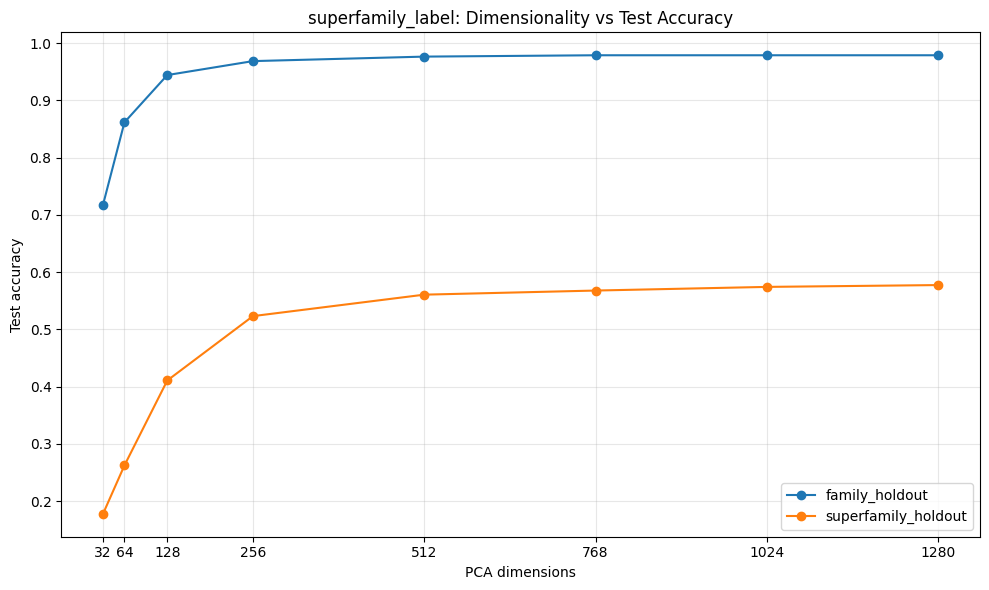

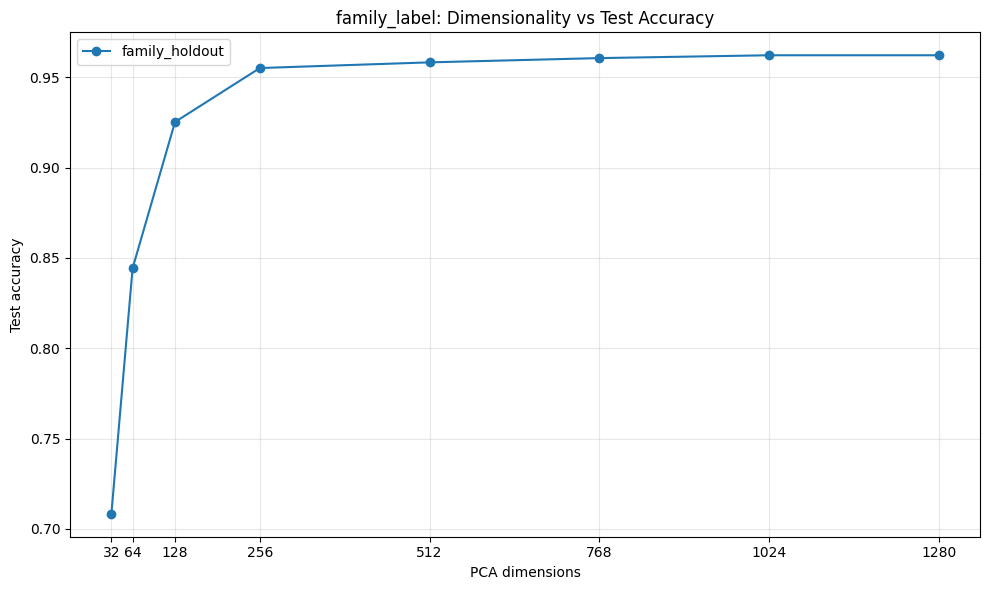

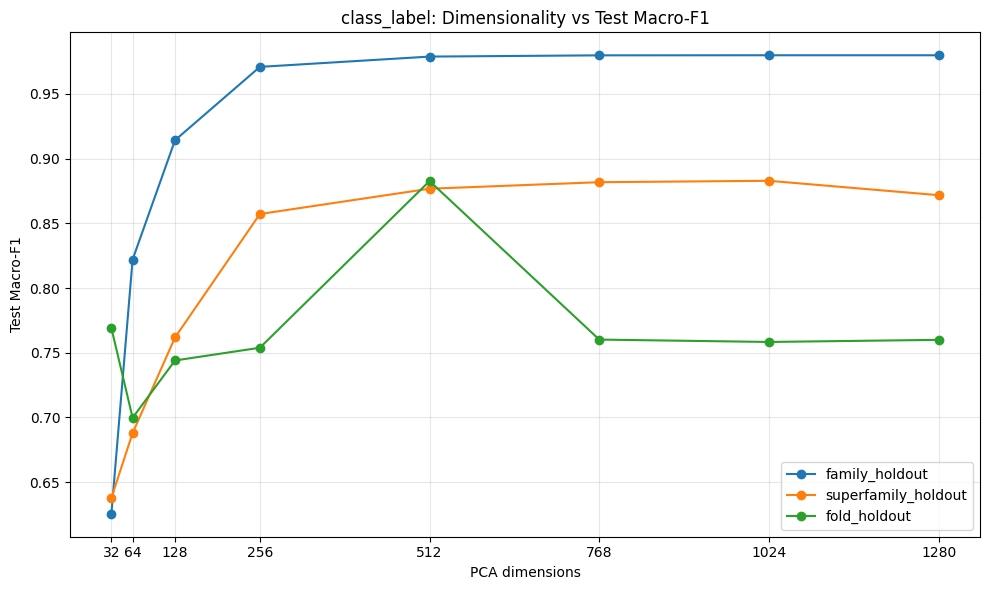

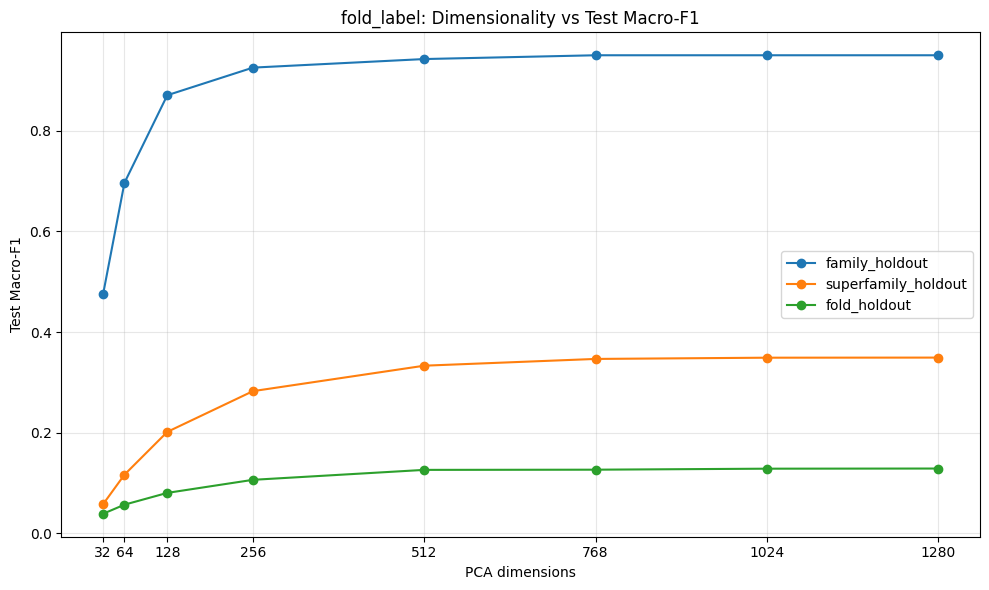

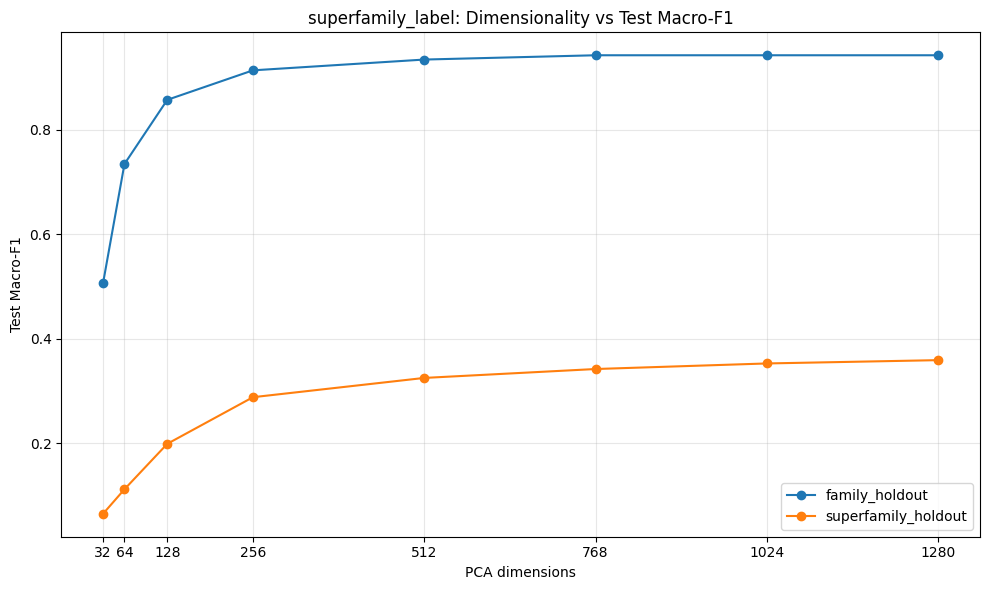

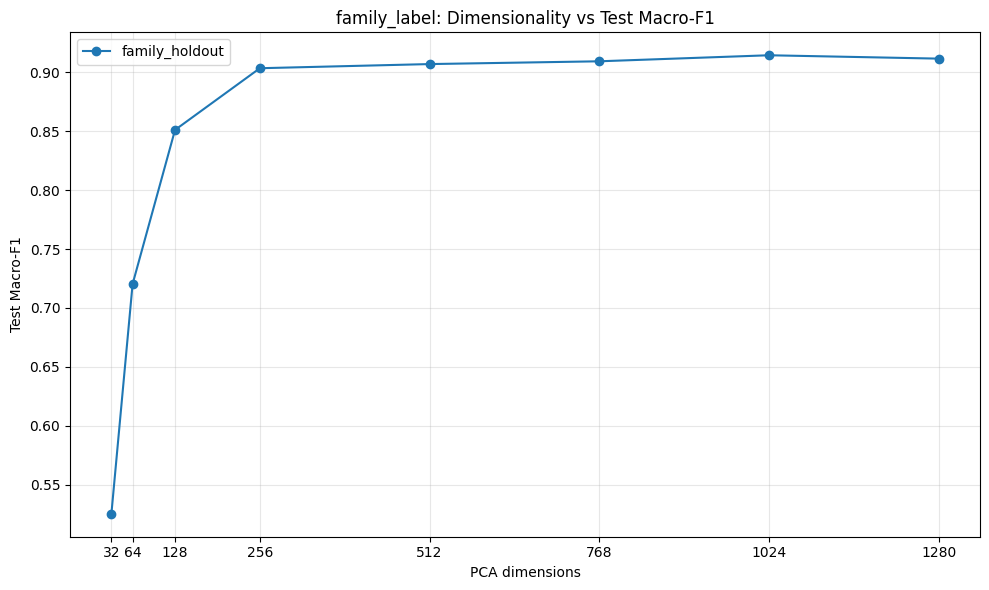

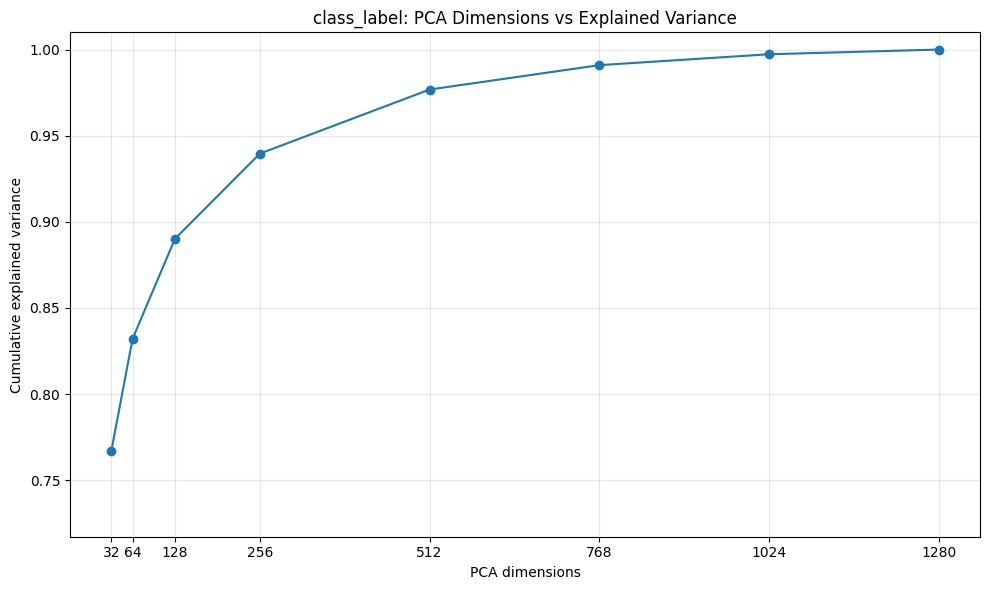

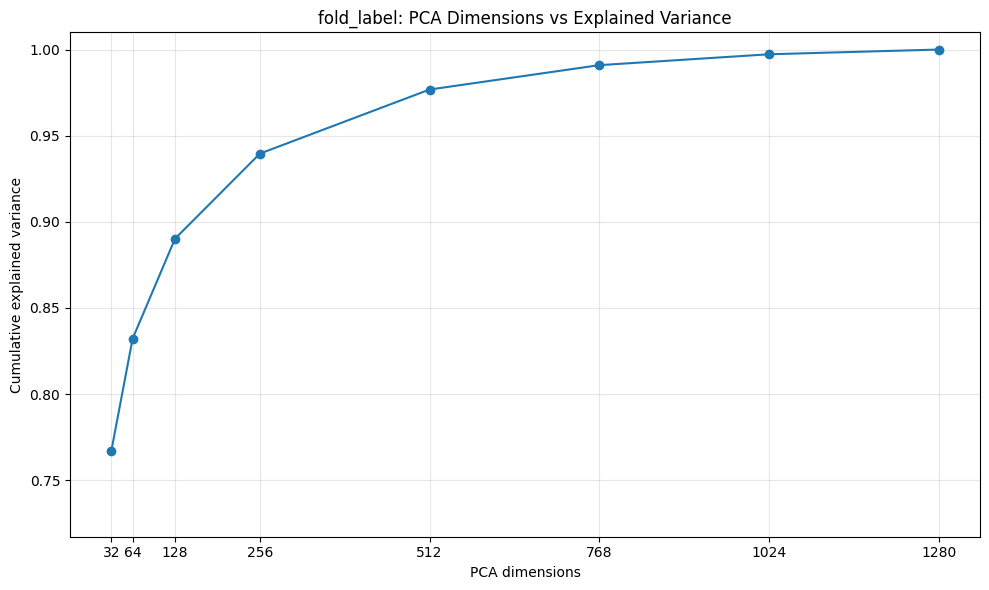

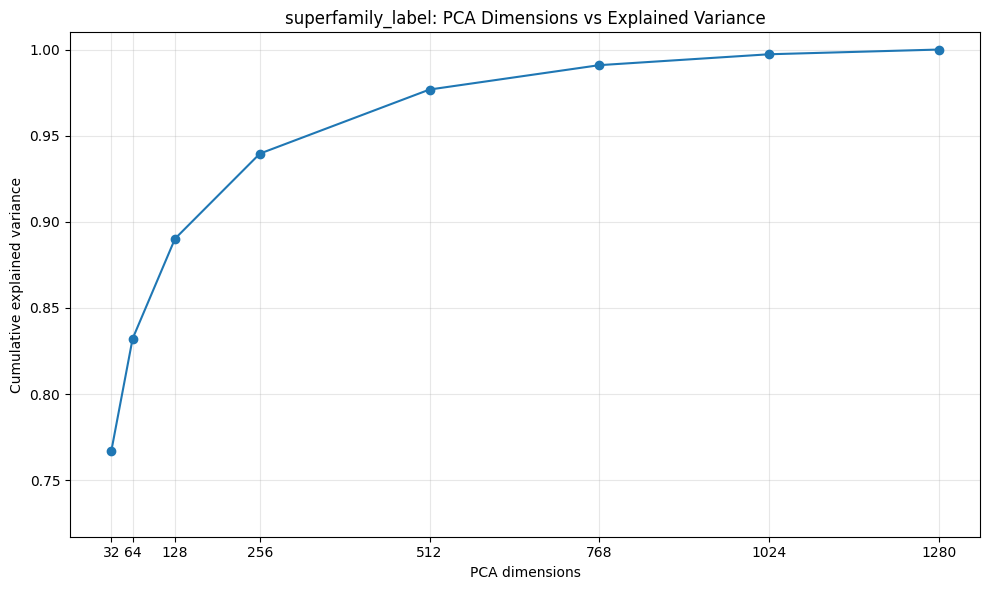

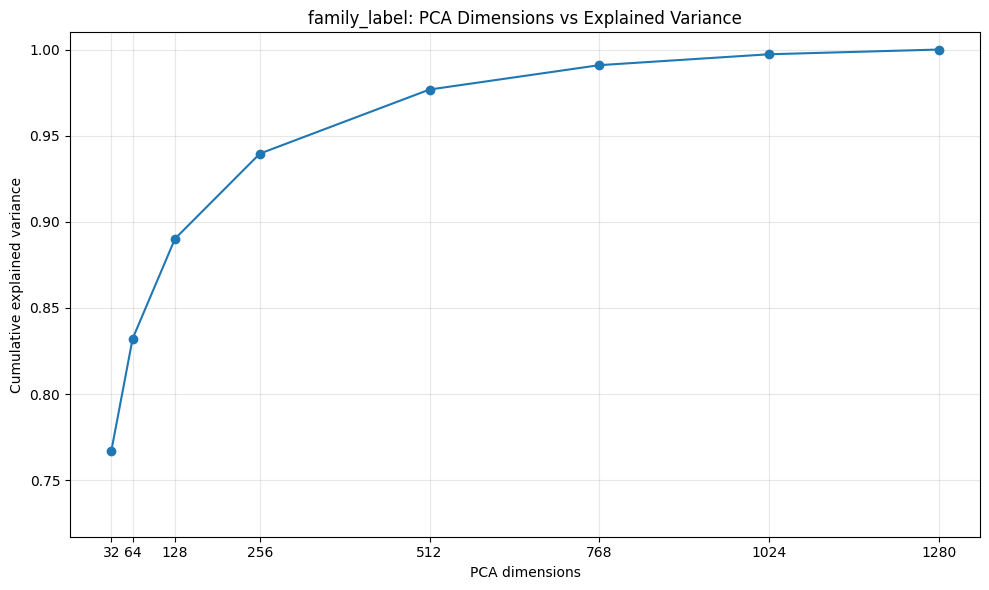



EXPERIMENT SUMMARY

Target    : class_label
Holdout   : family_holdout
Best D    : 768
Accuracy  : 0.9827
Macro-F1  : 0.9798
Balanced  : 0.9721
Variance  : 0.9909

Target    : class_label
Holdout   : fold_holdout
Best D    : 768
Accuracy  : 0.8900
Macro-F1  : 0.7602
Balanced  : 0.8857
Variance  : 0.9909

Target    : class_label
Holdout   : superfamily_holdout
Best D    : 1280
Accuracy  : 0.9282
Macro-F1  : 0.8718
Balanced  : 0.8378
Variance  : 1.0000

Target    : family_label
Holdout   : family_holdout
Best D    : 1024
Accuracy  : 0.9623
Macro-F1  : 0.9146
Balanced  : 0.9374
Variance  : 0.9973

Target    : fold_label
Holdout   : family_holdout
Best D    : 768
Accuracy  : 0.9796
Macro-F1  : 0.9497
Balanced  : 0.9603
Variance  : 0.9909

Target    : fold_label
Holdout   : fold_holdout
Best D    : 1024
Accuracy  : 0.3162
Macro-F1  : 0.1286
Balanced  : 0.1778
Variance  : 0.9973

Target    : fold_label
Holdout   : superfamily_holdout
Best D    : 1280
Accuracy  : 0.6196
Macro-F1  : 0.3492
B

In [4]:
from pathlib import Path
import json
import hashlib
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, EsmModel

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder


# =============================================================================
# CONFIGURATION
# =============================================================================

SEED = 42

MODEL_NAME = "facebook/esm2_t33_650M_UR50D"

DATASET_NAME = "remote_homology"

BASE_DIR = Path("protein_dimensionality_experiments")
DATA_DIR = BASE_DIR / "data" / DATASET_NAME / DATASET_NAME

EMBEDDING_DIR = BASE_DIR / "embeddings"
RESULTS_DIR = BASE_DIR / "results"

EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "remote_homology_train.json"
VALID_FILE = DATA_DIR / "remote_homology_valid.json"

TEST_FILES = {
    "family_holdout": DATA_DIR / "remote_homology_test_family_holdout.json",
    "superfamily_holdout": DATA_DIR / "remote_homology_test_superfamily_holdout.json",
    "fold_holdout": DATA_DIR / "remote_homology_test_fold_holdout.json",
}

TARGET_COLUMNS = [
    "class_label",
    "fold_label",
    "superfamily_label",
    "family_label",
]

DIMS = [
    32,
    64,
    128,
    256,
    512,
    768,
    1024,
    1280,
]

BATCH_SIZE = 16
MAX_LENGTH = 512
CLASSIFIER_MAX_ITER = 1000

# Change to False if you want to force embedding regeneration.
USE_EMBEDDING_CACHE = True


# =============================================================================
# REPRODUCIBILITY
# =============================================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

warnings.filterwarnings("ignore")


# =============================================================================
# DEVICE
# =============================================================================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")


print("=" * 80)
print("REMOTE HOMOLOGY HIERARCHICAL DIMENSIONALITY EXPERIMENT")
print("=" * 80)

print(f"Device: {DEVICE}")
print(f"Model : {MODEL_NAME}")
print(f"Seed  : {SEED}")


# =============================================================================
# FILE CHECKS
# =============================================================================

required_files = [TRAIN_FILE, VALID_FILE, *TEST_FILES.values()]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


# =============================================================================
# DATA LOADING
# =============================================================================

def load_json_records(path):
    with open(path, "r") as f:
        data = json.load(f)

    if not isinstance(data, list):
        raise ValueError(f"Expected a list of records in {path}")

    return data


train_records = load_json_records(TRAIN_FILE)
valid_records = load_json_records(VALID_FILE)

test_records = {
    name: load_json_records(path)
    for name, path in TEST_FILES.items()
}


print("\n" + "=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print(f"Train sequences: {len(train_records)}")
print(f"Valid sequences: {len(valid_records)}")

for name, records in test_records.items():
    print(f"{name.replace('_', ' ').title()} sequences: {len(records)}")


# =============================================================================
# RECORD VALIDATION
# =============================================================================

def validate_records(records, split_name):
    if len(records) == 0:
        raise ValueError(f"{split_name} is empty.")

    required = {
        "id",
        "primary",
        *TARGET_COLUMNS,
    }

    missing = set()

    for record in records:
        missing.update(required - set(record.keys()))

    if missing:
        raise ValueError(
            f"{split_name} is missing fields: {sorted(missing)}"
        )


validate_records(train_records, "train")
validate_records(valid_records, "valid")

for name, records in test_records.items():
    validate_records(records, name)


# =============================================================================
# BASIC DATASET DIAGNOSTICS
# =============================================================================

def label_summary(records, split_name):
    rows = []

    for target in TARGET_COLUMNS:
        values = [record[target] for record in records]

        rows.append(
            {
                "split": split_name,
                "target": target,
                "n_sequences": len(values),
                "n_unique_labels": len(set(values)),
                "min_label": min(values),
                "max_label": max(values),
            }
        )

    return pd.DataFrame(rows)


diagnostic_tables = [
    label_summary(train_records, "train"),
    label_summary(valid_records, "valid"),
]

for name, records in test_records.items():
    diagnostic_tables.append(
        label_summary(records, name)
    )

label_diagnostics = pd.concat(
    diagnostic_tables,
    ignore_index=True,
)

print("\n" + "=" * 80)
print("LABEL CARDINALITY")
print("=" * 80)

print(label_diagnostics.to_string(index=False))

label_diagnostics.to_csv(
    RESULTS_DIR / "remote_homology_label_diagnostics.csv",
    index=False,
)


# =============================================================================
# TRAIN / TEST LABEL OVERLAP
# =============================================================================

train_labels = {
    target: set(record[target] for record in train_records)
    for target in TARGET_COLUMNS
}


overlap_rows = []

for test_name, records in test_records.items():

    for target in TARGET_COLUMNS:

        test_labels = set(
            record[target]
            for record in records
        )

        overlap = train_labels[target].intersection(test_labels)

        unseen = test_labels - train_labels[target]

        overlap_rows.append(
            {
                "holdout": test_name,
                "target": target,
                "train_unique_labels": len(train_labels[target]),
                "test_unique_labels": len(test_labels),
                "overlapping_labels": len(overlap),
                "unseen_test_labels": len(unseen),
                "test_label_coverage": (
                    len(overlap) / len(test_labels)
                    if len(test_labels) > 0
                    else 0.0
                ),
            }
        )


overlap_df = pd.DataFrame(overlap_rows)

print("\n" + "=" * 80)
print("TRAIN / TEST LABEL OVERLAP")
print("=" * 80)

print(overlap_df.to_string(index=False))

overlap_df.to_csv(
    RESULTS_DIR / "remote_homology_train_test_label_overlap.csv",
    index=False,
)


# =============================================================================
# EXTRACT SEQUENCES
# =============================================================================

def sequence_from_record(record):
    return str(record["primary"])


# =============================================================================
# EMBEDDING CACHE
# =============================================================================
#
# Important:
# We cache embeddings by sequence ID rather than by split.
#
# This allows the same ESM-2 representation to be reused across:
#
#   - family holdout
#   - superfamily holdout
#   - fold holdout
#
# without embedding the same sequence multiple times.
# =============================================================================

all_records_by_id = {}

all_record_groups = [
    train_records,
    valid_records,
]

for records in test_records.values():
    all_record_groups.append(records)


for records in all_record_groups:
    for record in records:

        record_id = str(record["id"])

        if record_id in all_records_by_id:

            existing_sequence = all_records_by_id[record_id]["primary"]

            if existing_sequence != record["primary"]:
                raise ValueError(
                    f"Sequence mismatch for duplicated ID: {record_id}"
                )

        else:
            all_records_by_id[record_id] = record


print("\n" + "=" * 80)
print("EMBEDDING INVENTORY")
print("=" * 80)

print(
    f"Unique protein sequences across all splits: "
    f"{len(all_records_by_id)}"
)


# =============================================================================
# LOAD ESM-2
# =============================================================================

print("\nLoading ESM-2...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = EsmModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

HIDDEN_SIZE = model.config.hidden_size

print(f"Hidden size: {HIDDEN_SIZE}")
print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters())}"
)


# =============================================================================
# EMBEDDING CACHE PATH
# =============================================================================

cache_key = hashlib.md5(
    "|".join(
        [
            MODEL_NAME,
            str(MAX_LENGTH),
            str(len(all_records_by_id)),
        ]
    ).encode()
).hexdigest()[:12]


EMBEDDING_CACHE = (
    EMBEDDING_DIR
    / f"remote_homology_all_esm2_{HIDDEN_SIZE}d_{cache_key}.npz"
)


# =============================================================================
# ESM-2 EMBEDDING FUNCTION
# =============================================================================

@torch.no_grad()
def embed_sequences(sequences):

    embeddings = []

    for start in range(0, len(sequences), BATCH_SIZE):

        batch_sequences = sequences[
            start:start + BATCH_SIZE
        ]

        encoded = tokenizer(
            batch_sequences,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        )

        encoded = {
            key: value.to(DEVICE)
            for key, value in encoded.items()
        }

        outputs = model(**encoded)

        hidden = outputs.last_hidden_state

        attention_mask = encoded["attention_mask"]

        # Exclude BOS and EOS.
        residue_mask = attention_mask.clone()

        residue_mask[:, 0] = 0

        sequence_lengths = attention_mask.sum(dim=1)

        for i, length in enumerate(sequence_lengths):
            residue_mask[i, length - 1] = 0

        mask = residue_mask.unsqueeze(-1).float()

        pooled = (
            hidden * mask
        ).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

        embeddings.append(
            pooled.cpu().numpy().astype(np.float32)
        )

        processed = min(
            start + BATCH_SIZE,
            len(sequences),
        )

        if (
            processed % 1000 == 0
            or processed == len(sequences)
        ):
            print(
                f"  Embedded {processed:,} / "
                f"{len(sequences):,}"
            )

    return np.concatenate(
        embeddings,
        axis=0,
    )


# =============================================================================
# GENERATE / LOAD EMBEDDINGS
# =============================================================================

all_ids = list(all_records_by_id.keys())

if USE_EMBEDDING_CACHE and EMBEDDING_CACHE.exists():

    print("\nLoading cached embeddings:")
    print(EMBEDDING_CACHE)

    cache = np.load(
        EMBEDDING_CACHE,
        allow_pickle=False,
    )

    cached_ids = cache["ids"]
    cached_embeddings = cache["embeddings"]

    cached_id_to_index = {
        str(record_id): i
        for i, record_id in enumerate(cached_ids)
    }

    missing_ids = [
        record_id
        for record_id in all_ids
        if record_id not in cached_id_to_index
    ]

    if not missing_ids:

        embedding_by_id = {
            str(record_id): cached_embeddings[i]
            for i, record_id in enumerate(cached_ids)
        }

    else:

        print(
            f"\nCache is missing {len(missing_ids)} sequences."
        )

        missing_sequences = [
            all_records_by_id[record_id]["primary"]
            for record_id in missing_ids
        ]

        new_embeddings = embed_sequences(
            missing_sequences
        )

        embedding_by_id = {
            str(record_id): cached_embeddings[i]
            for i, record_id in enumerate(cached_ids)
        }

        for i, record_id in enumerate(missing_ids):
            embedding_by_id[record_id] = new_embeddings[i]

        all_ids = list(embedding_by_id.keys())

        final_embeddings = np.vstack(
            [embedding_by_id[record_id] for record_id in all_ids]
        )

        np.savez_compressed(
            EMBEDDING_CACHE,
            ids=np.asarray(all_ids),
            embeddings=final_embeddings,
        )

else:

    print("\nGenerating ESM-2 embeddings...")

    all_sequences = [
        all_records_by_id[record_id]["primary"]
        for record_id in all_ids
    ]

    all_embeddings = embed_sequences(
        all_sequences
    )

    embedding_by_id = {
        record_id: all_embeddings[i]
        for i, record_id in enumerate(all_ids)
    }

    np.savez_compressed(
        EMBEDDING_CACHE,
        ids=np.asarray(all_ids),
        embeddings=all_embeddings,
    )


print("\nEmbeddings saved:")
print(EMBEDDING_CACHE)

print(
    f"Embedding dimension: "
    f"{next(iter(embedding_by_id.values())).shape[0]}"
)


# =============================================================================
# CONVERT RECORDS TO EMBEDDINGS + LABELS
# =============================================================================

def records_to_arrays(records, target):

    ids = [
        str(record["id"])
        for record in records
    ]

    X = np.vstack(
        [
            embedding_by_id[record_id]
            for record_id in ids
        ]
    )

    y = np.asarray(
        [
            int(record[target])
            for record in records
        ],
        dtype=np.int64,
    )

    return X, y


X_train_full = None

# All targets share the same protein embeddings.
X_train_full, _ = records_to_arrays(
    train_records,
    TARGET_COLUMNS[0],
)

X_valid_full, _ = records_to_arrays(
    valid_records,
    TARGET_COLUMNS[0],
)


# =============================================================================
# CLASSIFICATION VALIDITY
# =============================================================================

def classification_is_valid(y_train, y_test):

    train_classes = set(y_train)
    test_classes = set(y_test)

    unseen_test_classes = test_classes - train_classes

    return len(unseen_test_classes) == 0


# =============================================================================
# DIMENSIONALITY EXPERIMENT
# =============================================================================

results = []


for target in TARGET_COLUMNS:

    print("\n")
    print("=" * 80)
    print(f"TARGET: {target}")
    print("=" * 80)

    X_train, y_train = records_to_arrays(
        train_records,
        target,
    )

    X_valid, y_valid = records_to_arrays(
        valid_records,
        target,
    )

    print(
        f"Training classes: {len(np.unique(y_train))}"
    )

    print(
        f"Validation classes: {len(np.unique(y_valid))}"
    )

    # -------------------------------------------------------------------------
    # PCA
    # -------------------------------------------------------------------------

    print("\nFitting PCA on training embeddings...")

    pca = PCA(
        n_components=HIDDEN_SIZE,
        random_state=SEED,
    )

    X_train_pca = pca.fit_transform(X_train)

    X_valid_pca = pca.transform(X_valid)

    explained_variance = pca.explained_variance_ratio_.cumsum()

    for holdout_name, test_records_current in test_records.items():

        X_test, y_test = records_to_arrays(
            test_records_current,
            target,
        )

        valid_classification = classification_is_valid(
            y_train,
            y_test,
        )

        train_classes = set(y_train)
        test_classes = set(y_test)

        unseen_test_classes = test_classes - train_classes

        print("\n" + "-" * 80)
        print(f"HOLDOUT: {holdout_name}")
        print("-" * 80)

        print(
            f"Train classes: {len(train_classes)}"
        )

        print(
            f"Test classes : {len(test_classes)}"
        )

        print(
            f"Unseen test classes: "
            f"{len(unseen_test_classes)}"
        )

        if not valid_classification:

            print(
                "\nClassification SKIPPED for this "
                "target/holdout combination."
            )

            print(
                "Reason: test contains labels that do not "
                "occur in training."
            )

            for D in DIMS:

                results.append(
                    {
                        "target": target,
                        "holdout": holdout_name,
                        "D": D,
                        "train_accuracy": np.nan,
                        "valid_accuracy": np.nan,
                        "test_accuracy": np.nan,
                        "train_macro_f1": np.nan,
                        "valid_macro_f1": np.nan,
                        "test_macro_f1": np.nan,
                        "test_balanced_accuracy": np.nan,
                        "explained_variance": explained_variance[D - 1],
                        "classification_valid": False,
                        "unseen_test_classes": len(
                            unseen_test_classes
                        ),
                    }
                )

            continue

        X_test_pca = pca.transform(X_test)

        # ---------------------------------------------------------------------
        # Dimension sweep
        # ---------------------------------------------------------------------

        for D in DIMS:

            print(
                f"\nTarget={target} | "
                f"Holdout={holdout_name} | "
                f"D={D}"
            )

            Xtr = X_train_pca[:, :D]
            Xv = X_valid_pca[:, :D]
            Xte = X_test_pca[:, :D]

            classifier = LogisticRegression(
                max_iter=CLASSIFIER_MAX_ITER,
                random_state=SEED,
                n_jobs=-1,
            )

            classifier.fit(
                Xtr,
                y_train,
            )

            train_pred = classifier.predict(Xtr)
            valid_pred = classifier.predict(Xv)
            test_pred = classifier.predict(Xte)

            train_accuracy = accuracy_score(
                y_train,
                train_pred,
            )

            valid_accuracy = accuracy_score(
                y_valid,
                valid_pred,
            )

            test_accuracy = accuracy_score(
                y_test,
                test_pred,
            )

            train_macro_f1 = f1_score(
                y_train,
                train_pred,
                average="macro",
                zero_division=0,
            )

            valid_macro_f1 = f1_score(
                y_valid,
                valid_pred,
                average="macro",
                zero_division=0,
            )

            test_macro_f1 = f1_score(
                y_test,
                test_pred,
                average="macro",
                zero_division=0,
            )

            test_balanced_accuracy = balanced_accuracy_score(
                y_test,
                test_pred,
            )

            current_explained_variance = (
                explained_variance[D - 1]
            )

            print(
                f"Train accuracy : "
                f"{train_accuracy:.4f}"
            )

            print(
                f"Valid accuracy : "
                f"{valid_accuracy:.4f}"
            )

            print(
                f"Test accuracy  : "
                f"{test_accuracy:.4f}"
            )

            print(
                f"Test Macro-F1  : "
                f"{test_macro_f1:.4f}"
            )

            print(
                f"Balanced Acc.  : "
                f"{test_balanced_accuracy:.4f}"
            )

            print(
                f"Explained var. : "
                f"{current_explained_variance:.4f}"
            )

            results.append(
                {
                    "target": target,
                    "holdout": holdout_name,
                    "D": D,
                    "train_accuracy": train_accuracy,
                    "valid_accuracy": valid_accuracy,
                    "test_accuracy": test_accuracy,
                    "train_macro_f1": train_macro_f1,
                    "valid_macro_f1": valid_macro_f1,
                    "test_macro_f1": test_macro_f1,
                    "test_balanced_accuracy": test_balanced_accuracy,
                    "explained_variance": current_explained_variance,
                    "classification_valid": True,
                    "unseen_test_classes": 0,
                }
            )


# =============================================================================
# SAVE RESULTS
# =============================================================================

results_df = pd.DataFrame(results)

results_path = (
    RESULTS_DIR
    / "remote_homology_hierarchical_dimensionality_results.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)

print("\n")
print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

print(
    results_df.to_string(index=False)
)

print("\nResults saved:")
print(results_path)


# =============================================================================
# VALID RESULTS ONLY
# =============================================================================

valid_results = results_df[
    results_df["classification_valid"]
].copy()


# =============================================================================
# BEST DIMENSION PER TARGET / HOLDOUT
# =============================================================================

best_rows = []

if not valid_results.empty:

    for (target, holdout), group in valid_results.groupby(
        ["target", "holdout"]
    ):

        best = group.loc[
            group["test_accuracy"].idxmax()
        ]

        best_rows.append(
            {
                "target": target,
                "holdout": holdout,
                "best_D_by_accuracy": int(best["D"]),
                "test_accuracy": best["test_accuracy"],
                "test_macro_f1": best["test_macro_f1"],
                "test_balanced_accuracy": (
                    best["test_balanced_accuracy"]
                ),
                "explained_variance": best["explained_variance"],
            }
        )


best_df = pd.DataFrame(best_rows)

best_path = (
    RESULTS_DIR
    / "remote_homology_hierarchical_best_results.csv"
)

best_df.to_csv(
    best_path,
    index=False,
)

print("\n" + "=" * 80)
print("BEST RESULTS")
print("=" * 80)

if not best_df.empty:
    print(best_df.to_string(index=False))
else:
    print("No valid classification experiments were available.")

print("\nSaved:")
print(best_path)


# =============================================================================
# PLOT 1 — ACCURACY VS DIMENSION
# =============================================================================

if not valid_results.empty:

    for target in valid_results["target"].unique():

        target_results = valid_results[
            valid_results["target"] == target
        ]

        plt.figure(figsize=(10, 6))

        for holdout in target_results["holdout"].unique():

            subset = target_results[
                target_results["holdout"] == holdout
            ]

            plt.plot(
                subset["D"],
                subset["test_accuracy"],
                marker="o",
                label=holdout,
            )

        plt.xlabel("PCA dimensions")
        plt.ylabel("Test accuracy")
        plt.title(
            f"{target}: Dimensionality vs Test Accuracy"
        )

        plt.xticks(DIMS)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plot_path = (
            RESULTS_DIR
            / f"remote_homology_{target}_accuracy_vs_D.png"
        )

        plt.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


# =============================================================================
# PLOT 2 — MACRO-F1 VS DIMENSION
# =============================================================================

if not valid_results.empty:

    for target in valid_results["target"].unique():

        target_results = valid_results[
            valid_results["target"] == target
        ]

        plt.figure(figsize=(10, 6))

        for holdout in target_results["holdout"].unique():

            subset = target_results[
                target_results["holdout"] == holdout
            ]

            plt.plot(
                subset["D"],
                subset["test_macro_f1"],
                marker="o",
                label=holdout,
            )

        plt.xlabel("PCA dimensions")
        plt.ylabel("Test Macro-F1")
        plt.title(
            f"{target}: Dimensionality vs Test Macro-F1"
        )

        plt.xticks(DIMS)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plot_path = (
            RESULTS_DIR
            / f"remote_homology_{target}_macro_f1_vs_D.png"
        )

        plt.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


# =============================================================================
# PLOT 3 — EXPLAINED VARIANCE
# =============================================================================

if not valid_results.empty:

    for target in valid_results["target"].unique():

        target_results = valid_results[
            valid_results["target"] == target
        ]

        # Explained variance is identical across holdouts
        # for the same training representation.
        subset = (
            target_results[
                ["D", "explained_variance"]
            ]
            .drop_duplicates()
            .sort_values("D")
        )

        plt.figure(figsize=(10, 6))

        plt.plot(
            subset["D"],
            subset["explained_variance"],
            marker="o",
        )

        plt.xlabel("PCA dimensions")
        plt.ylabel("Cumulative explained variance")
        plt.title(
            f"{target}: PCA Dimensions vs Explained Variance"
        )

        plt.xticks(DIMS)
        plt.ylim(
            max(
                0,
                subset["explained_variance"].min() - 0.05,
            ),
            1.01,
        )

        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plot_path = (
            RESULTS_DIR
            / f"remote_homology_{target}_explained_variance.png"
        )

        plt.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


# =============================================================================
# SUMMARY
# =============================================================================

print("\n")
print("=" * 80)
print("EXPERIMENT SUMMARY")
print("=" * 80)

if not best_df.empty:

    for _, row in best_df.iterrows():

        print(
            f"\nTarget    : {row['target']}"
        )

        print(
            f"Holdout   : {row['holdout']}"
        )

        print(
            f"Best D    : {row['best_D_by_accuracy']}"
        )

        print(
            f"Accuracy  : "
            f"{row['test_accuracy']:.4f}"
        )

        print(
            f"Macro-F1  : "
            f"{row['test_macro_f1']:.4f}"
        )

        print(
            f"Balanced  : "
            f"{row['test_balanced_accuracy']:.4f}"
        )

        print(
            f"Variance  : "
            f"{row['explained_variance']:.4f}"
        )


print("\nOutput directory:")
print(RESULTS_DIR.resolve())

print("\nExperiment complete.")

  # Analysis and Discussion

## 1. Overview

The dimensionality experiment was designed to determine whether downstream classification performance depends strongly on the dimensionality of the ESM-2 protein representation, and whether this relationship changes with the level of biological similarity between training and test proteins.

Unlike the initial five-class experiment, where test accuracy remained close to the 20% random-chance baseline across dimensionalities, the TAPE Remote Homology dataset produces substantially stronger and more informative results. Classification performance varies systematically with representation dimensionality, but the magnitude of this effect depends strongly on the biological relationship between the training and test sets.

The experiment therefore provides evidence that **representation dimensionality can affect the accessibility of biological information to downstream classifiers**, but that dimensionality alone does not determine generalization performance. The biological difficulty of the evaluation split is equally important.

---

## 2. Dimensionality Has a Strong Effect on Class-Level Classification

The clearest result is observed for `class_label` classification on the family-holdout test set.

| Dimensionality | Test Accuracy | Test Macro-F1 | Explained Variance |
| -------------: | ------------: | ------------: | -----------------: |
|             32 |        0.8373 |        0.6241 |             0.7676 |
|             64 |        0.9009 |        0.8220 |             0.8326 |
|            128 |        0.9607 |        0.9147 |             0.8906 |
|            256 |        0.9764 |        0.9709 |             0.9399 |
|            512 |        0.9811 |        0.9789 |             0.9770 |
|            768 |        0.9827 |        0.9798 |             0.9910 |
|           1024 |        0.9827 |        0.9799 |             0.9973 |
|           1280 |        0.9827 |        0.9799 |             1.0000 |

There is a pronounced improvement as dimensionality increases from 32 to approximately 256 dimensions.

Test accuracy increases from **83.73% at 32D to 97.64% at 256D**, an absolute improvement of approximately 13.9 percentage points. Macro-F1 shows an even more important improvement, increasing from **0.6241 to 0.9709**.

This indicates that very aggressive compression removes information that is useful for classification.

However, the improvement becomes much smaller after approximately 256–512 dimensions. Accuracy reaches 98.11% at 512D and 98.27% at 768D, after which it effectively plateaus.

This creates an important distinction between **information retention** and **useful downstream information**. Although PCA continues to preserve additional variance as dimensionality increases, the classifier does not obtain a corresponding improvement in predictive performance after approximately 512–768 dimensions.

---

## 3. The Most Interesting Result: PCA Variance and Classification Performance Are Not Equivalent

One of the most interesting observations is the different behaviour of explained variance and classification accuracy.

At 256 dimensions, PCA preserves approximately **93.99%** of the variance, while at 512 dimensions it preserves **97.70%**. At 768 dimensions, this increases further to **99.10%**, and at 1024 dimensions it reaches **99.73%**.

Despite this large increase in retained variance, classification performance changes very little after 512–768 dimensions.

For example:

* 256D → 97.64% test accuracy
* 512D → 98.11%
* 768D → 98.27%
* 1024D → 98.27%
* 1280D → 98.27%

Therefore, retaining an additional ~6% of PCA variance between 256D and 768D produces less than a one-percentage-point improvement in accuracy.

This demonstrates that **PCA explained variance should not be interpreted as a direct measure of biologically relevant information**.

PCA identifies directions of high statistical variance in the embedding space. A low-variance direction may nevertheless contain information that is highly discriminative for a particular biological task. Conversely, high-variance directions may contain information that contributes little to classification.

The results therefore support evaluating dimensionality using both:

1. representation-level measures such as explained variance; and
2. task-level measures such as accuracy and macro-F1.

---

## 4. 256D Is a Strong Compression Point, but Not Necessarily the Optimal Dimension

The results provide evidence for a useful compression regime.

The original ESM-2 representation has 1280 dimensions. Reducing this representation to 256 dimensions removes **80% of the dimensions**, while retaining approximately **93.99% of the PCA variance**.

More importantly, the classification performance at 256D is already very high:

> **97.64% test accuracy and 0.9709 macro-F1.**

Increasing the representation to 512D improves accuracy by only approximately 0.47 percentage points. Increasing it further to 768D improves accuracy by another approximately 0.16 percentage points.

Thus, for this particular classification task and evaluation split, the majority of the useful downstream signal appears to be accessible within a substantially smaller representation than the original 1280-dimensional embedding.

However, the results do **not** justify claiming that 256D is universally optimal. The family-level experiments and harder biological holdouts show that the required dimensionality depends on the task and generalization regime.

A more appropriate conclusion is that **256D represents an effective compact representation for this specific class-level classification task**, while higher dimensions may become useful for more difficult forms of biological generalization.

---

## 5. Family-Holdout Performance Is Extremely High

The family-holdout result is particularly striking.

At 768D, the classifier achieves:

* Test accuracy: **98.27%**
* Test macro-F1: **0.9798**

The corresponding training accuracy is 96.77%, while validation accuracy is 90.76%.

The high test performance should be interpreted in the context of the TAPE split definition. The family-holdout evaluation does not represent completely arbitrary proteins. The test proteins remain related to proteins represented in the training distribution at higher levels of the structural hierarchy.

Consequently, the classifier appears to transfer class-level information successfully across proteins that are separated at the family level but retain broader biological relationships.

This is an important distinction from asking whether ESM-2 can classify completely novel biological families. The experiment demonstrates strong generalization under this particular hierarchical split, rather than unrestricted generalization to unseen biological concepts.

---

## 6. Biological Holdout Difficulty Has a Larger Effect Than Dimensionality at Higher Levels

The comparison between the different holdout levels is perhaps the most important result of the entire experiment.

For `class_label`, the best observed results were approximately:

| Test Holdout        | Best Dimensionality | Test Accuracy | Test Macro-F1 |
| ------------------- | ------------------: | ------------: | ------------: |
| Family holdout      |                768D |        0.9827 |        0.9798 |
| Superfamily holdout |               1280D |        0.9282 |        0.8718 |
| Fold holdout        |                768D |        0.8900 |        0.7602 |

The performance decreases substantially as the biological separation between training and test examples becomes more demanding.

Most importantly, increasing dimensionality does **not** eliminate this performance gap.

For example, the class-level family-holdout task reaches approximately 98.3% accuracy, whereas the fold-holdout task reaches approximately 89.0%, despite both using the same underlying ESM-2 representation.

This suggests that the limiting factor in the harder experiments is not simply the number of dimensions available to the classifier.

Instead, the results are consistent with the interpretation that **biological distribution shift becomes an increasingly important source of difficulty as the test proteins become more distant from the training examples**.

---

## 7. Increasing Dimensionality Cannot Fully Compensate for Biological Distribution Shift

The results provide an important negative finding.

If poor classification performance were primarily caused by insufficient representation dimensionality, we would expect increasing D to consistently recover performance on the harder holdout sets.

This does not occur.

For class-level classification:

* Family holdout reaches approximately 98.3%.
* Superfamily holdout reaches approximately 92.8%.
* Fold holdout reaches approximately 89.0%.

The superfamily-holdout task reaches its best result at the full 1280D representation, suggesting that additional representation capacity can still be useful for this harder task.

However, the fold-holdout task reaches its best observed result at 768D rather than 1280D, and its performance remains substantially below the family-holdout result.

Therefore, **more dimensions do not automatically produce better biological generalization**.

This is an important result for interpreting protein language model representations: representation capacity and generalization are related, but they are not interchangeable.

---

## 8. Hierarchical Labels Reveal Different Generalization Behaviour

The experiment also examined multiple levels of the Remote Homology hierarchy:

* `class_label`
* `fold_label`
* `superfamily_label`
* `family_label`

This reveals that the dimensionality-performance relationship depends not only on the test split but also on what biological property is being predicted.

For example, `family_label` classification on the family-holdout set achieved approximately:

* **96.23% accuracy**
* **0.9146 macro-F1**
* **0.9374 balanced accuracy**
* approximately **99.73% explained variance at 1024D**

This is lower than class-level classification, demonstrating that predicting increasingly specific biological categories is more difficult even when the evaluation labels overlap with the training label space.

This is scientifically useful because it suggests that ESM-2 embeddings contain information at multiple levels of the protein similarity hierarchy, but that the accessibility and separability of this information depends on the prediction task.

---

## 9. The Fold-Level Result Highlights a Particularly Difficult Generalization Problem

An especially interesting result occurs for `fold_label` classification on the fold-holdout set.

The best observed result was approximately:

* **1024D**
* Test accuracy: **31.62%**
* Test macro-F1: **0.1286**
* Balanced accuracy: **0.1778**

This is dramatically lower than the corresponding performance on the family-holdout setting.

This result should not be interpreted simply as evidence that ESM-2 embeddings are poor representations.

Rather, it demonstrates that the evaluation protocol is testing a much more difficult form of generalization. The fold-holdout setting removes entire structural folds from the training distribution, creating a substantially different biological generalization problem.

The result therefore highlights an important principle:

> **High performance on a protein classification task does not necessarily imply successful generalization to biologically distant proteins.**

A representation can perform extremely well when related biological structure remains represented in the training distribution while performing substantially worse when the evaluation requires extrapolation beyond that distribution.

---

## 10. Training and Test Performance Do Not Show Classical Overfitting in the Same Way as the Original Dataset

The original five-class experiment produced approximately 20% training and test accuracy across dimensionalities, indicating that the classifier was effectively unable to extract useful discriminative information from that dataset under the tested setup.

The TAPE Remote Homology results are fundamentally different.

For class-level family-holdout classification, training accuracy increases from approximately 80.0% at 32D to 97.1% at 1280D, while test accuracy increases from 83.7% to 98.3%.

The classifier therefore learns a highly discriminative representation of the classes.

Interestingly, test accuracy is sometimes higher than training accuracy, particularly at lower dimensions. This is not necessarily evidence of a methodological problem; the family-holdout test set has a different class composition and may contain examples that are easier to classify at the class level than some of the training examples.

More importantly, the results do not show the same pattern observed in the original dataset where training accuracy itself remained near chance.

This strongly suggests that the earlier 20% result cannot be explained simply by ESM-2 lacking biologically useful information.

---

## 11. Sequence Truncation Is Unlikely to Explain the Main Results

The sequence-length analysis provides an additional useful control.

The training sequences have:

* Mean length: approximately 167 residues
* Median length: approximately 134 residues
* Maximum length: 1419 residues

Only approximately **1.22% of training sequences exceed the 512-residue maximum sequence length**, with similarly small proportions in validation and test sets.

Therefore, although ESM-2 truncation affects a small subset of proteins, truncation is unlikely to explain the large dimensionality-dependent performance differences observed in this experiment.

The dominant pattern is instead associated with representation dimensionality and biological holdout difficulty.

---

## 12. Implications for the Original 20% Accuracy Result

The Remote Homology experiment provides an important control for interpreting the original five-class experiment.

In the original dataset, increasing the learned projection dimension from 64D to 1280D produced test accuracies clustered around the 20% chance level.

In contrast, the Remote Homology dataset produces a strong dimensionality-performance relationship:

**83.73% → 98.27% accuracy as dimensionality increases from 32D to 768D.**

This demonstrates that the ESM-2 representation and the downstream classification pipeline are capable of producing highly accurate predictions when the dataset contains a strong and learnable biological signal.

Therefore, the original ~20% result should not be attributed to PCA dimensionality reduction alone.

The evidence instead suggests that the original result is associated with properties of the original dataset, labels, preprocessing, class definitions, or the relationship between the sequences and their assigned labels.

This experiment therefore substantially weakens the hypothesis:

> "The classifier only achieved approximately 20% because the protein embeddings were compressed too aggressively."

The TAPE experiment demonstrates that substantial compression can still preserve highly discriminative information when the underlying task contains a strong biological signal.

---

## 13. Main Scientific Findings

The combined results support several conclusions.

### Finding 1 — Dimensionality matters, but mainly at lower dimensions

Very aggressive compression from 1280D to 32–64D causes a substantial decrease in performance.

However, performance approaches a plateau between approximately 512D and 768D for class-level family-holdout classification.

### Finding 2 — PCA explained variance is not a sufficient criterion for selecting dimensionality

Although explained variance continues to increase toward 100%, downstream classification performance saturates much earlier.

Therefore, representation variance and task-relevant biological information should be evaluated separately.

### Finding 3 — A compact representation can retain most useful predictive information

The 256D representation retains approximately 93.99% of PCA variance while achieving 97.64% test accuracy for class-level family-holdout classification.

This demonstrates substantial compression without a corresponding loss of predictive performance.

### Finding 4 — Biological holdout difficulty is a major determinant of performance

The same ESM-2 representation achieves very different performance depending on whether the test proteins are held out at the family, superfamily, or fold level.

This indicates that evaluation design is critical when measuring protein representation quality.

### Finding 5 — More dimensions do not guarantee better biological generalization

Increasing dimensionality does not close the performance gap between easier and harder biological holdouts.

This suggests that some limitations arise from the biological distribution shift itself rather than from insufficient embedding dimensionality.

### Finding 6 — The original ~20% result is unlikely to be explained solely by PCA compression

The strong performance on TAPE Remote Homology demonstrates that ESM-2 embeddings contain usable biological information and that the experimental pipeline can recover it.

The original result therefore requires investigation of the original dataset and task rather than attributing the result exclusively to dimensionality reduction.

---

## 14. Limitations and Interpretation

Several limitations should be considered.

First, PCA is an unsupervised dimensionality-reduction method. Explained variance therefore describes statistical reconstruction of the embedding space rather than preservation of biological information.

Second, the classification experiments use logistic regression as the downstream classifier. The results therefore measure the information accessible through a relatively simple linear decision boundary after PCA rather than the maximum information theoretically present in the embeddings.

Third, some hierarchical label/holdout combinations contain labels that are unseen during training. These cases cannot be interpreted as conventional closed-set classification and were therefore excluded from the standard classification analysis. In particular, strong performance on the family-holdout `family_label` task should not be interpreted as evidence that the model can classify completely unseen protein families.

Finally, the experiments use a single random seed for the dimensionality sweep. The observed trends are strong, but the exact differences between neighbouring dimensionalities should be confirmed with repeated seeds before treating small performance differences as statistically meaningful.

---

## 15. Discussion

Taken together, these experiments suggest that the relationship between protein representation dimensionality and downstream biological performance is **task-dependent rather than monotonic**.

At very low dimensionalities, compression removes information that is useful for discrimination. Between approximately 128D and 512D, recovering additional dimensions produces substantial improvements. Beyond approximately 512–768D, however, additional dimensions provide diminishing returns for the class-level family-holdout task.

At the same time, the experiments reveal that dimensionality is only one component of the generalization problem. The substantial reduction in performance under more difficult biological holdouts demonstrates that **the relationship between training and test distributions can be more important than the raw dimensionality of the representation**.

This leads to a more informative way of thinking about protein language model representations:

$$
\text{Downstream performance}
=
f(\text{representation dimensionality},
\text{task complexity},
\text{biological similarity},
\text{distribution shift})
$$

Rather than searching for a single universally optimal embedding dimension, dimensionality should therefore be evaluated jointly with the biological generalization regime.

The results also suggest that an effective protein representation need not preserve every dimension of the original ESM-2 embedding to retain strong predictive performance. For some tasks, a substantially compressed representation can preserve most of the information required by a downstream classifier.

The most important scientific observation is therefore not simply that "higher dimensions perform better." Instead, the results show a **diminishing-return regime** in which increasing dimensionality initially recovers useful biological information, followed by a plateau where additional embedding dimensions contribute little to the evaluated task.

---

## 16. Working Conclusion

The Remote Homology experiments provide strong evidence that ESM-2 representations contain biologically relevant information that can be accessed through downstream classification, and that representation dimensionality influences how much of this information is accessible to a linear classifier.

However, the effect is strongly task-dependent. For class-level prediction under the family-holdout setting, performance approaches saturation around 512–768 dimensions, while more difficult hierarchical holdouts remain substantially harder even when using the full 1280-dimensional representation.

Consequently, **dimensionality reduction is not inherently responsible for poor biological classification performance**. The original ~20% result cannot be explained by PCA compression alone, because the same ESM-2 representation exhibits strong dimensionality-dependent performance on a biologically structured benchmark.

The next stage of the study should therefore distinguish between:

* information lost through PCA,
* information present in the original ESM-2 representation,
* information accessible to linear versus nonlinear classifiers, and
* information that remains transferable under increasingly difficult biological distribution shifts.

This motivates direct comparison of **raw 1280D ESM-2 embeddings, PCA-reduced embeddings, and learned projections**, followed by repeated-seed experiments and validation on an independent protein family dataset such as Pfam.
